In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit
import corner
from lmfit import minimize, Parameters
from astropy.io import fits
from uncertainties import ufloat
import uncertainties.unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
linmixPath = '/home/benjamin/Documents/linmix/'
os.sys.path.append(magePath)
os.sys.path.append(linmixPath)
import linmix

from magE.plotutils import * 
from magE.constutils import *

In [2]:
print('MagE Resolution (km/s):', round(299792.458 / 4100))

MagE Resolution (km/s): 73


In [3]:
# Literature

def B20(tempx, tempy):
    Tx = np.linspace(0.0, 100, 500)
    if (tempx == 'TO2' and tempy == 'TN2') or (tempy == 'TO2' and tempx == 'TN2'):
        Ty = (Tx - 1.203) / 1.004
    if (tempx == 'TS3' and tempy == 'TO3') or (tempy == 'TS3' and tempx == 'TO3'):
        Ty = (1.795 * Tx) - 8.167
    if (tempx == 'TS3' and tempy == 'TN2') or (tempy == 'TS3' and tempx == 'TN2'):
        Ty = (1.522 * Tx) - 4.576
    return Tx/10, Ty/10

def G92(tempx, tempy):
    Tx = np.linspace(0.0, 10.0, 500)
    if (tempx == 'TS3' and tempy == 'TO3') or (tempy == 'TS3' and tempx == 'TO3'):
        Ty = (0.83 * Tx) + 0.17
    if (tempx == 'TO2' and tempy == 'TO3') or (tempy == 'TO2' and tempx == 'TO3'):
        Ty = (0.7 * Tx) + 0.3
    return Tx, Ty

def PM17(tempx, tempy):
    Tx = np.linspace(0.0, 10.0, 500)
    if (tempx == 'TS2' and tempy == 'TO2') or (tempy == 'TS2' and tempx == 'TO2'):
        Ty = (0.71 * Tx) + 0.12
    if (tempx == 'TS3' and tempy == 'TO3') or (tempy == 'TS3' and tempx == 'TO3'):
        Ty = (1.19 * Tx) + 0.32
    if (tempx == 'TO2' and tempy == 'TO3') or (tempy == 'TO2' and tempx == 'TO3'):
        Ty = 2 * Tx / (1 + (0.8 * Tx))
    if (tempx == 'TN2' and tempy == 'TO3') or (tempy == 'TN2' and tempx == 'TO3'):
        Ty = 1.85 * Tx / (1 + (0.72 * Tx))
    return Tx, Ty

def R21(tempx, tempy):
    Tx = np.linspace(0.0, 10.0, 500)
    if (tempx == 'TO3' and tempy == 'TN2') or (tempx == 'TN2' and tempy == 'TO3'):
        Ty = (0.79 * Tx) + 0.16
    if (tempx == 'TS3' and tempy == 'TN2') or (tempx == 'TN2' and tempy == 'TS3'):
        Ty = (0.68 * Tx) + 0.28
    if (tempx == 'TO2' and tempy == 'TN2') or (tempx == 'TN2' and tempy == 'TO2'):
        Ty = (0.45 * Tx) + 0.36
    if (tempx == 'TO3' and tempy == 'TS3') or (tempx == 'TS3' and tempy == 'TO3'):
        Ty = (Tx - 0.36) / 0.63
    return Tx, Ty

def PM17_den(density=100):
    Tx = np.linspace(0.1, 10.0, 500)
    num = 1.2 + (0.002 * density) + (4.2 / density)
    den = 0.08 + (Tx**-1) + (0.003 * density) + (2.5 / density)
    Ty = num / den
    return Tx, Ty

# Temden analysis from clouds

In [6]:
# Temperatures
temden_measured = pd.read_csv(magePath+'results/metals/temden_measured_lstsq.csv')
tm_dict = {}

In [7]:
for key in temden_measured.keys():
    tm_dict[key] = temden_measured[key].to_numpy()

## Linear fit 

In [6]:
np.random.seed(999)

lm_o3s3 = linmix.LinMix(tm_dict['tOIII'][~np.isnan(tm_dict['tSIII'])], tm_dict['tSIII'][~np.isnan(tm_dict['tSIII'])],
                       tm_dict['tOIII_err'][~np.isnan(tm_dict['tSIII'])], tm_dict['tSIII_err'][~np.isnan(tm_dict['tSIII'])],
                       K=2)
lm_o3s3.run_mcmc(silent=True)

In [7]:
np.random.seed(999)

lm_o3o2 = linmix.LinMix(tm_dict['tOIII'], tm_dict['tOII'],
                       tm_dict['tOIII_err'], tm_dict['tOII_err'],
                       K=2)
lm_o3o2.run_mcmc(silent=True)

In [8]:
np.random.seed(999)

lm_s3o2 = linmix.LinMix(tm_dict['tSIII'][~np.isnan(tm_dict['tSIII'])], tm_dict['tOII'][~np.isnan(tm_dict['tSIII'])],
                       tm_dict['tSIII_err'][~np.isnan(tm_dict['tSIII'])], tm_dict['tOII_err'][~np.isnan(tm_dict['tSIII'])],
                       K=2)
lm_s3o2.run_mcmc(silent=True)

In [9]:
alpha_o3s3 = np.mean(lm_o3s3.chain['alpha'])
alpha_o3s3_std = np.std(lm_o3s3.chain['alpha'])
beta_o3s3 = np.mean(lm_o3s3.chain['beta'])
beta_o3s3_std = np.std(lm_o3s3.chain['beta'])
sig_int_o3s3 = upy.sqrt(ufloat(np.mean(lm_o3s3.chain['sigsqr']),
                                np.std(lm_o3s3.chain['sigsqr'])))

alpha_o3o2 = np.mean(lm_o3o2.chain['alpha'])
alpha_o3o2_std = np.std(lm_o3o2.chain['alpha'])
beta_o3o2 = np.mean(lm_o3o2.chain['beta'])
beta_o3o2_std = np.std(lm_o3o2.chain['beta'])
sig_int_o3o2 = upy.sqrt(ufloat(np.mean(lm_o3o2.chain['sigsqr']),
                                np.std(lm_o3o2.chain['sigsqr'])))

alpha_s3o2 = np.mean(lm_s3o2.chain['alpha'])
alpha_s3o2_std = np.std(lm_s3o2.chain['alpha'])
beta_s3o2 = np.mean(lm_s3o2.chain['beta'])
beta_s3o2_std = np.std(lm_s3o2.chain['beta'])
sig_int_s3o2 = upy.sqrt(ufloat(np.mean(lm_s3o2.chain['sigsqr']),
                                np.std(lm_s3o2.chain['sigsqr'])))

# Non-linear functional form

In [10]:
params_o2o3 = Parameters()

params_o2o3.add('u', value=2.0)
params_o2o3.add('v', value=0.8)

def residuals_o2o3(params_o2o3, x, data, uncertainty):
    
    u = params_o2o3['u']
    v = params_o2o3['v']
    
    x = tm_dict['tOIII']
    
    model = u / ((x**-1) + v)
    
    return (model - tm_dict['tOII']) / tm_dict['tOII_err']

In [11]:
np.random.seed(999)
out_fit_o2o3 = minimize(residuals_o2o3, params_o2o3, args=(1, 1, 1),
                       method='leastsq')
out_fit_o2o3.params

name,value,standard error,relative error,initial value,min,max,vary
u,9.70211475,35.6518655,(367.46%),2.0,-inf,inf,True
v,9.38533209,37.3275383,(397.72%),0.8,-inf,inf,True


# Quadratic

In [12]:
params_q_o2o3 = Parameters()

#params_q_o2o3.add('a0', value=-0.5, max=0.)
params_q_o2o3.add('a1', value=1.3, min=0.)
params_q_o2o3.add('a2', value=-0.2, max=0.)

def residuals_q_o2o3(params_q_o2o3, x, data, uncertainty):
    
    #a0 = params_q_o2o3['a0']
    a1 = params_q_o2o3['a1']
    a2 = params_q_o2o3['a2']
    
    x = tm_dict['tOIII']
    
    model = (a1 * x) + (a2 * (x**2))
    
    return (model - tm_dict['tOII']) / tm_dict['tOII_err']

In [13]:
np.random.seed(999)
out_fit_q_o2o3 = minimize(residuals_q_o2o3, params_q_o2o3, args=(1, 1, 1),
                       method='leastsq')
out_fit_q_o2o3.params

name,value,standard error,relative error,initial value,min,max,vary
a1,1.40576085,0.19061039,(13.56%),1.3,0.00000000,inf,True
a2,-0.50623365,0.13794952,(27.25%),-0.2,-inf,0.00000000,True


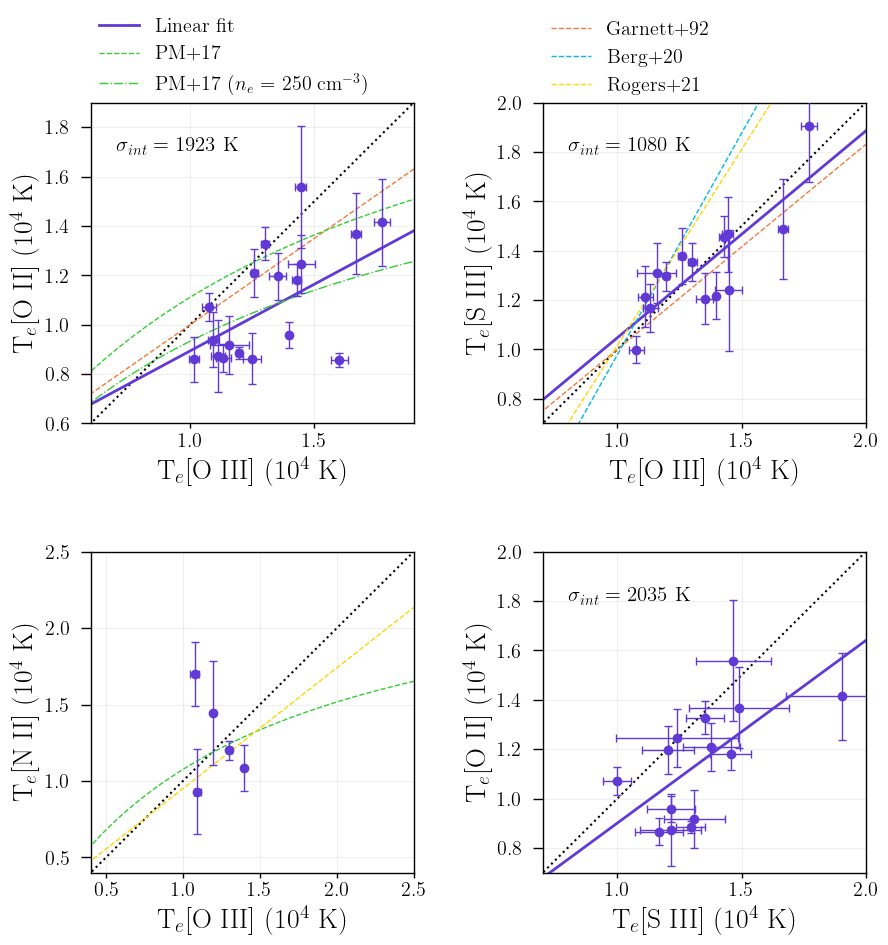

In [19]:
texPlot('on')
fig, axs = plt.subplots(2, 2)
fig.set_size_inches((10, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


axs[0, 0].errorbar(tm_dict['tOIII'], tm_dict['tOII'],
               xerr=tm_dict['tOIII_err'], yerr=tm_dict['tOII_err'],
               marker='o', markersize=6, capsize=3,
               ls='', elinewidth=1, color=c[2], zorder=100)

axs[0, 0].plot(np.arange(0.5, 2.0, 0.1), np.arange(0.5, 2.0, 0.1),
            ls=':', color='black')
axs[0, 0].plot(np.arange(0.5, 5.0, 0.1), alpha_o3o2 + (np.arange(0.5, 5.0, 0.1) * beta_o3o2),
              color=c[2], lw=2, label='Linear fit')

axs[0, 0].set_xlabel(r'T$_{e}$[O III] ($10^{4}$ K)')
axs[0, 0].set_ylabel(r'T$_{e}$[O II] ($10^{4}$ K)')
axs[0, 0].set_xlim(0.6, 1.9)
axs[0, 0].set_ylim(0.6, 1.9)
axs[0, 0].plot(G92('TO3', 'TO2')[0], G92('TO3', 'TO2')[1],
              ls='--', lw=1, color=cz[0])
axs[0, 0].plot(PM17('TO3', 'TO2')[0], PM17('TO3', 'TO2')[1],
              ls='--', lw=1, label='PM+17', color='limegreen')
axs[0, 0].plot(PM17_den(250)[0], PM17_den(250)[1],
              ls='-.', lw=1, color='limegreen', label='PM+17 ($n_{e}$ = 250 cm$^{-3}$)')
#axs[0, 0].plot(PM17_den(600)[0], PM17_den(600)[1],
#              ls='-.', lw=2, color='limegreen', label='PM+2017 ($n_{e}$ = 600 cm$^{-3}$)')
axs[0, 0].text(0.7, 1.7, s=r'$\sigma_{int} =$ '+str(round(upy.nominal_values(sig_int_o3o2)*10000))+' K', fontsize=15)
axs[0, 0].legend(loc=(0.0, 1.0))



axs[0, 1].errorbar(tm_dict['tOIII'], tm_dict['tSIII'],
               xerr=tm_dict['tOIII_err'], yerr=tm_dict['tSIII_err'],
               marker='o', markersize=6, capsize=3,
               ls='', elinewidth=1, color=c[2], zorder=100)
axs[0, 1].plot(np.arange(0.5, 2.5, 0.1), np.arange(0.5, 2.5, 0.1),
            ls=':', color='black')
axs[0, 1].plot(np.arange(0.5, 5.0, 0.1), (beta_o3s3 * np.arange(0.5, 5.0, 0.1)) + alpha_o3s3,
              color=c[2], lw=2)
axs[0, 1].plot(G92('TO3', 'TS3')[0], G92('TO3', 'TS3')[1],
              ls='--', lw=1, color=cz[0], label='Garnett+92')
axs[0, 1].plot(B20('TO3', 'TS3')[0], B20('TO3', 'TS3')[1],
              ls='--', lw=1, label='Berg+20', color=c[0])
axs[0, 1].plot(R21('TO3', 'TS3')[0], R21('TO3', 'TS3')[1],
              ls='--', lw=1, color='gold', label='Rogers+21')
axs[0, 1].set_xlabel(r'T$_{e}$[O III] ($10^{4}$ K)')
axs[0, 1].set_ylabel(r'T$_{e}$[S III] ($10^{4}$ K)')
axs[0, 1].set_xlim(0.7, 2.0)
axs[0, 1].set_ylim(0.7, 2.0)
axs[0, 1].text(0.8, 1.8, s=r'$\sigma_{int} =$ '+str(round(upy.nominal_values(sig_int_o3s3)*10000))+' K', fontsize=15)
axs[0, 1].legend(loc=(0.0, 1.0))


axs[1, 0].errorbar(tm_dict['tOIII'], tm_dict['tNII'],
               xerr=tm_dict['tOIII_err'], yerr=tm_dict['tNII_err'],
               marker='o', markersize=6, capsize=3,
               ls='', elinewidth=1, color=c[2], zorder=100)
axs[1, 0].plot(np.arange(0.0, 3.0, 0.1), np.arange(0.0, 3.0, 0.1),
            ls=':', color='black')
axs[1, 0].set_xlabel(r'T$_{e}$[O III] ($10^{4}$ K)')
axs[1, 0].set_ylabel(r'T$_{e}$[N II] ($10^{4}$ K)')
axs[1, 0].set_xlim(0.4, 2.5)
axs[1, 0].set_ylim(0.4, 2.5)
axs[1, 0].plot(PM17('TN2', 'TO3')[0], PM17('TN2', 'TO3')[1],
              ls='--', lw=1, color='limegreen')
axs[1, 0].plot(R21('TN2', 'TO3')[0], R21('TN2', 'TO3')[1],
              ls='--', lw=1, color='gold')



axs[1, 1].errorbar(tm_dict['tSIII'], tm_dict['tOII'],
               xerr=tm_dict['tSIII_err'], yerr=tm_dict['tOII_err'],
               marker='o', markersize=6, capsize=3,
               ls='', elinewidth=1, color=c[2], zorder=100)
axs[1, 1].plot(np.arange(0.0, 3.0, 0.1), np.arange(0.0, 3.0, 0.1),
            ls=':', color='black')
axs[1, 1].plot(np.arange(0.5, 5.0, 0.1), (beta_s3o2 * np.arange(0.5, 5.0, 0.1)) + alpha_s3o2,
              color=c[2], lw=2)
axs[1, 1].set_xlabel(r'T$_{e}$[S III] ($10^{4}$ K)')
axs[1, 1].set_ylabel(r'T$_{e}$[O II] ($10^{4}$ K)')
axs[1, 1].set_xlim(0.7, 2.0)
axs[1, 1].set_ylim(0.7, 2.0)
axs[1, 1].text(0.8, 1.8, s=r'$\sigma_{int} =$ '+str(round(upy.nominal_values(sig_int_s3o2)*10000))+' K', fontsize=15)


axs[0, 0].grid(visible=True, alpha=0.2)
axs[0, 1].grid(visible=True, alpha=0.2)
axs[1, 0].grid(visible=True, alpha=0.2)
axs[1, 1].grid(visible=True, alpha=0.2)
#fig.savefig(magePath+'analysis/chapter4/temp_relations.pdf', bbox_inches='tight')

In [16]:
print('Slope [OIII] vs [OII] fit: {:.2f}'.format(ufloat(beta_o3o2, beta_o3o2_std)))
print('Intercept [OIII] vs [OII] fit: {:.2f}'.format(ufloat(alpha_o3o2, alpha_o3o2_std)))

Slope [OIII] vs [OII] fit: 0.54+/-0.26
Intercept [OIII] vs [OII] fit: 0.35+/-0.35


In [17]:
print('Slope [OIII] vs [SIII] fit: {:.2f}'.format(ufloat(beta_o3s3, beta_o3s3_std)))
print('Intercept [OIII] vs [SIII] fit: {:.2f}'.format(ufloat(alpha_o3s3, alpha_o3s3_std)))

Slope [OIII] vs [SIII] fit: 0.84+/-0.25
Intercept [OIII] vs [SIII] fit: 0.21+/-0.33


In [18]:
print('Slope [SIII] vs [OII] fit: {:.2f}'.format(ufloat(beta_s3o2, beta_s3o2_std)))
print('Intercept [SIII] vs [OII] fit: {:.2f}'.format(ufloat(alpha_s3o2, alpha_s3o2_std)))

Slope [SIII] vs [OII] fit: 0.74+/-0.58
Intercept [SIII] vs [OII] fit: 0.16+/-0.75


# Densitiy dependence

Text(0, 0.5, 'T$_{e}$[O II] ($10^{4}$ K)')

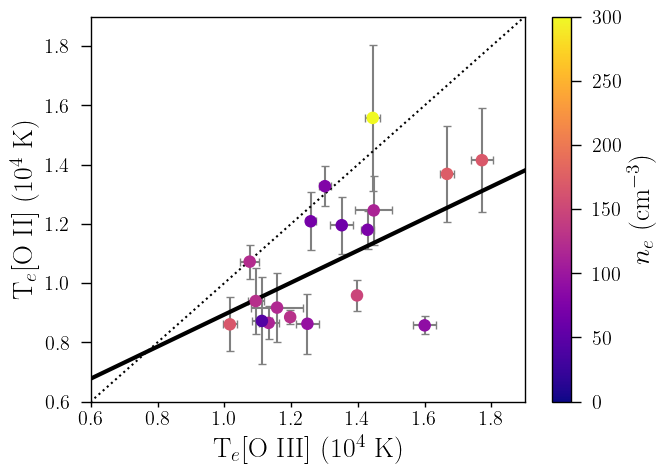

In [21]:
texPlot('on')
fig, axs = plt.subplots(1, 1)
fig.set_size_inches((7, 5))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


axs.errorbar(tm_dict['tOIII'], tm_dict['tOII'],
               xerr=tm_dict['tOIII_err'], yerr=tm_dict['tOII_err'],
               marker='', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black', zorder=0)
sc = axs.scatter(tm_dict['tOIII'], tm_dict['tOII'],
           s=64, c=tm_dict['ne'], vmin=0., vmax=300, zorder=5, cmap='plasma')
axs.plot(np.arange(0.5, 2.0, 0.1), np.arange(0.5, 2.0, 0.1),
            ls=':', color='black')
#axs[0, 0].plot(np.arange(0.5, 5.0, 0.1), u / ((np.arange(0.5, 5.0, 0.1)**-1) + v),
#              color=cz[1], lw=3, label='Best-fit')
plt.colorbar(sc, label=r'$n_{e}$ (cm$^{-3}$)')
axs.plot(np.arange(0.5, 5.0, 0.1), alpha_o3o2 + (np.arange(0.5, 5.0, 0.1) * beta_o3o2),
              color='black', lw=3, label='Best-fit')

axs.set_xlim(0.6, 1.9)
axs.set_ylim(0.6, 1.9)
axs.set_xlabel(r'T$_{e}$[O III] ($10^{4}$ K)')
axs.set_ylabel(r'T$_{e}$[O II] ($10^{4}$ K)')

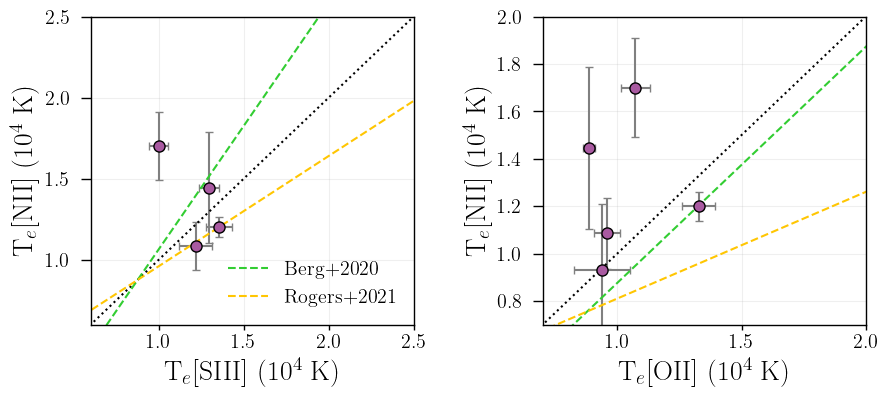

In [22]:
texPlot('on')
fig, axs = plt.subplots(1, 2)
fig.set_size_inches((10, 4))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


axs[0].errorbar(tm_dict['tSIII'], tm_dict['tNII'],
               xerr=tm_dict['tSIII_err'], yerr=tm_dict['tNII_err'],
               marker='o', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black')
axs[0].plot(np.arange(0.5, 3.0, 0.1), np.arange(0.5, 3.0, 0.1),
            ls=':', color='black')
axs[0].set_xlabel(r'T$_{e}$[SIII] ($10^{4}$ K)')
axs[0].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[0].set_xlim(0.6, 2.5)
axs[0].set_ylim(0.6, 2.5)
axs[0].plot(B20('TN2', 'TS3')[0], B20('TN2', 'TS3')[1],
              ls='--', label='Berg+2020', color='limegreen')
axs[0].plot(R21('TN2', 'TS3')[0], R21('TN2', 'TS3')[1],
              ls='--', label='Rogers+2021', color=c[3])
axs[0].grid(visible=True, alpha=0.2)
axs[0].legend()

axs[1].errorbar(tm_dict['tOII'], tm_dict['tNII'],
               xerr=tm_dict['tOII_err'], yerr=tm_dict['tNII_err'],
               marker='o', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black')
axs[1].plot(np.arange(0.5, 2.5, 0.1), np.arange(0.5, 2.5, 0.1),
            ls=':', color='black')
axs[1].set_xlabel(r'T$_{e}$[OII] ($10^{4}$ K)')
axs[1].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[1].set_xlim(0.7, 2.0)
axs[1].set_ylim(0.7, 2.0)
axs[1].plot(B20('TN2', 'TO2')[0], B20('TN2', 'TO2')[1],
              ls='--', label='Berg+2020', color='limegreen')
axs[1].plot(R21('TN2', 'TO2')[0], R21('TN2', 'TO2')[1],
              ls='--', label='Rogers+2021', color=c[3])
axs[1].grid(visible=True, alpha=0.2)

#fig.savefig('./nii_relations.pdf', bbox_inches='tight', facecolor='white');

In [23]:
print('Median ne: {:.2f}'.format(ufloat(np.median(tm_dict['ne']), np.median(tm_dict['ne_err']))))

Median ne: 116.93+/-51.52


## Probing abundances from relations

In [9]:
# Measured chemical abundances
abundance_measured = pd.read_csv(magePath+'results/metals/abundance_measured_lstsq.csv')

# Estimated chemical abundances from relations
abundance_estimated = pd.read_csv(magePath+'results/metals/abundance_estimated_lstsq_v2.csv')

In [10]:
# SDSS local galaxies 
izotov = fits.open(magePath+'analysis/Izotov_2006.fits')[1].data

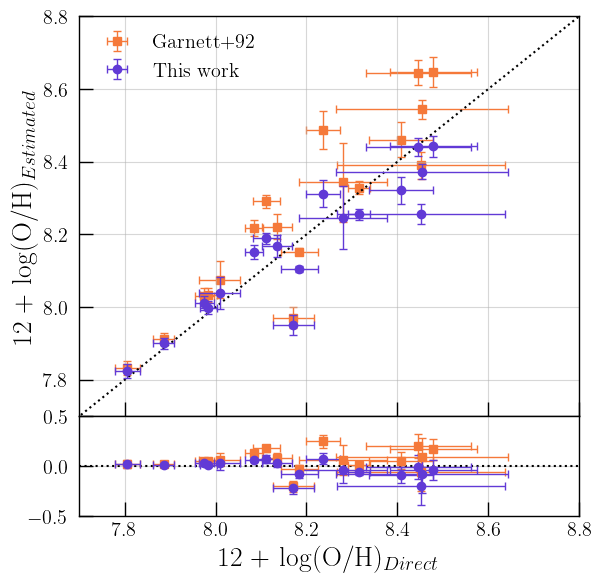

In [24]:
texPlot('on')
fig = plt.figure(1)
fig.set_size_inches(5, 5)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.grid(visible=True, alpha=0.5)
ax1.grid(visible=True, alpha=0.5)

ax.plot(np.arange(7.5, 9.5, 0.1), np.arange(7.5, 9.5, 0.1), color='black', ls=':')

ax.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_G92'],
            xerr=abundance_measured['log_OH_err'], yerr=abundance_estimated['log_OH_G92_err'],
            marker='s', markersize=6, capsize=3, elinewidth=1,
            ls='', color=cz[0], label='Garnett+92', zorder=0)

ax.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_tw'],
            xerr=abundance_measured['log_OH_err'], yerr=abundance_estimated['log_OH_tw_err'],
            marker='o', markersize=6, capsize=3, elinewidth=1,
            ls='', color=c[2], label='This work', zorder=5)

ax.set_xlim(7.7, 8.8)
ax1.set_xlim(7.7, 8.8)
ax.set_ylim(7.7, 8.8)
ax.set_xticklabels([])

ax1.axhline(0, color='black', ls=':')

G92_diff = upy.uarray(abundance_estimated['log_OH_G92'], abundance_estimated['log_OH_G92_err']) \
         - upy.uarray(abundance_measured['log_OH'], abundance_measured['log_OH_err'])

TW_diff = upy.uarray(abundance_estimated['log_OH_tw'], abundance_estimated['log_OH_tw_err']) \
         - upy.uarray(abundance_measured['log_OH'], abundance_measured['log_OH_err'])

ax1.errorbar(abundance_measured['log_OH'], upy.nominal_values(G92_diff),
            xerr=abundance_measured['log_OH_err'], yerr=upy.std_devs(G92_diff),
            marker='s', markersize=6, capsize=3, elinewidth=1,
            ls='', color=cz[0], label='Garnett+92')

ax1.errorbar(abundance_measured['log_OH'], upy.nominal_values(TW_diff),
            xerr=abundance_measured['log_OH_err'], yerr=upy.std_devs(TW_diff),
            marker='o', markersize=6, capsize=3, elinewidth=1,
            ls='', color=c[2], label='This work')



ax.legend()

ax1.set_ylim(-0.5, 0.5)

ax.set_ylabel(r'12 + log(O/H)$_{Estimated}$')
ax1.set_xlabel(r'12 + log(O/H)$_{Direct}$')

ax.tick_params(axis='both', length=10, direction='in')
ax1.tick_params(axis='both', length=10, direction='in')

fig.savefig(magePath+'analysis/chapter5/temprel_predictions.pdf', bbox_inches='tight')

In [27]:
print('Estimated scatter')
print('Linear fit:', round(np.std(abundance_estimated['log_OH_tw'] - abundance_measured['log_OH']), 4))
print('Garnett 1992:', round(np.std(abundance_estimated['log_OH_G92'] - abundance_measured['log_OH']), 4))

Estimated scatter
Linear fit: 0.0827
Garnett 1992: 0.1011


# Physical conditions

In [4]:
# SED fitting results
sed_results = fits.open('/home/benjamin/Documents/sed_fitting/old_pop_late_burst/results.fits')

# log(M*)
unc_m_star = upy.uarray(sed_results[1].data['bayes.stellar.m_star'],
                        sed_results[1].data['bayes.stellar.m_star_err'])
m_star = upy.nominal_values(upy.log10(unc_m_star))
m_star_err = upy.std_devs(upy.log10(unc_m_star))

# log(SFR)
unc_sfr = upy.uarray(sed_results[1].data['bayes.sfh.sfr'],
                     sed_results[1].data['bayes.sfh.sfr_err'])
sfr = upy.nominal_values(upy.log10(unc_sfr))
sfr_err = upy.std_devs(upy.log10(unc_sfr))

# To get E(B - V)
bal_dec = pd.read_csv('/home/benjamin/Documents/analogs/results/bal_decrements_lstsq.csv')

Text(0.5, 0, '$E(B - V)$')

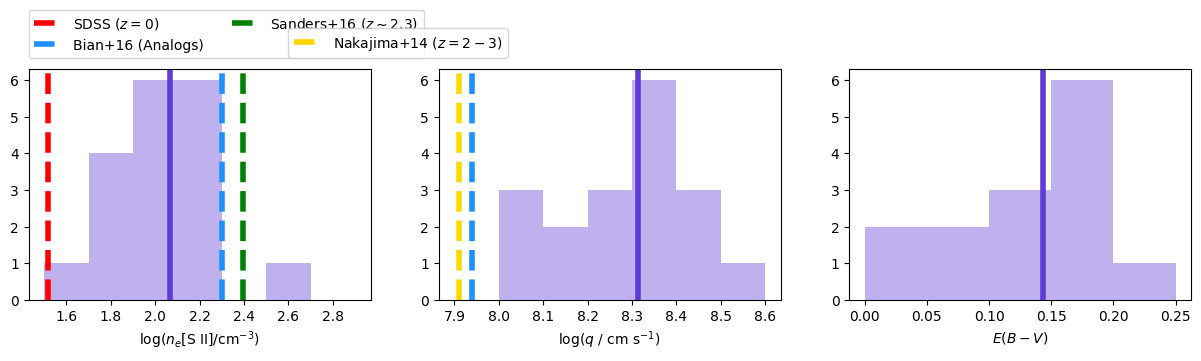

In [11]:
fig, axs = plt.subplots(1, 3)
fig.set_size_inches(15, 3)

# Electron density
axs[0].hist(np.log10(tm_dict['ne']), bins=np.arange(1.5, 3.0, 0.2), color=c[2], alpha=0.4)
axs[0].axvline(np.median(np.log10(tm_dict['ne'])), lw=4, color=c[2])
axs[0].axvline(np.log10(33), color='red', lw=4, ls='--', label=r'SDSS ($z = 0$)')
axs[0].axvline(np.log10(200), color='dodgerblue', lw=4, ls='--', label='Bian+16 (Analogs)')
axs[0].axvline(np.log10(250), color='green', lw=4, ls='--', label='Sanders+16 ($z \sim 2.3$)')
axs[0].set_xlabel(r'log($n_{e}$[S II]/cm$^{-3}$)')
axs[0].legend(ncols=2, loc=(0., 1.05))


# Ionization parameter
axs[1].hist(abundance_measured['log_q'], bins=np.arange(7.9, 8.7, 0.1), color=c[2], alpha=0.4)
axs[1].axvline(np.median(abundance_measured['log_q']), lw=4, color=c[2])
axs[1].axvline(7.94, color='dodgerblue', lw=4, ls='--')
axs[1].axvline(7.91, color='gold', lw=4, ls='--', label='Nakajima+14 ($z = 2 - 3$)')
axs[1].legend(loc=(-0.44, 1.05))
axs[1].set_xlabel(r'log($q$ / cm s$^{-1}$)')

# Color excess
axs[2].hist(bal_dec['E_BV'][bal_dec['E_BV'] > 0], bins=np.arange(0, 0.3, 0.05), color=c[2], alpha=0.4)
axs[2].axvline(np.median(bal_dec['E_BV'][bal_dec['E_BV'] > 0]), lw=4, color=c[2])
axs[2].set_xlabel('$E(B - V)$')
#fig.savefig(magePath+'analysis/chapter4/properties1.pdf', bbox_inches='tight')

In [12]:
magePath

'/home/benjamin/Documents/analogs/'

In [13]:
def rodrigueiro2011(log_m):
    log_SFR = -6.42 + (log_m * 0.79)
    return log_SFR

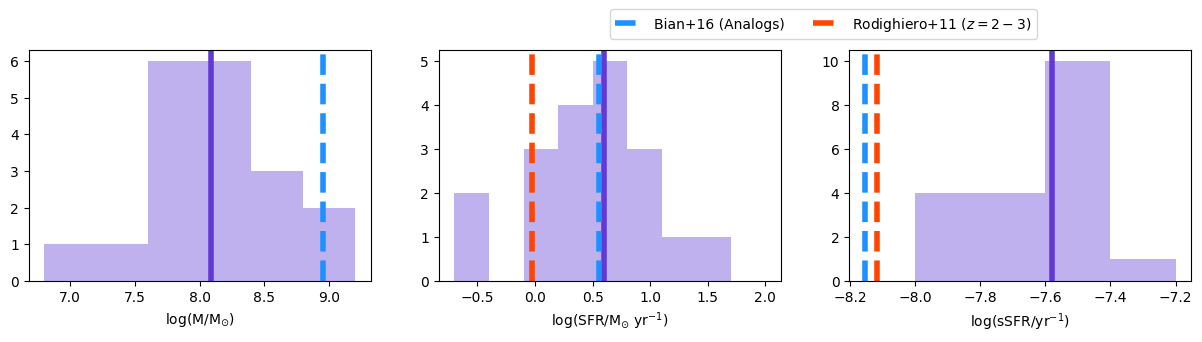

In [14]:
fig, axs = plt.subplots(1, 3)
fig.set_size_inches(15, 3)

# Stellar mass
axs[0].hist(m_star, bins=np.arange(6.8, 9.5, 0.4), color=c[2], alpha=0.4)
axs[0].axvline(np.median(m_star), lw=4, color=c[2])
axs[0].axvline(np.log10(9 * 1e8), color='dodgerblue', lw=4, ls='--', label='Bian+18 (Analogs)')
axs[0].set_xlabel(r'log(M/M$_{\odot}$)')

# SFR
axs[1].hist(sfr, bins=np.arange(-0.7, 2.0, 0.3), color=c[2], alpha=0.4)
axs[1].axvline(np.median(sfr), lw=4, color=c[2])
axs[1].axvline(np.log10(3.6), color='dodgerblue', lw=4, ls='--', label='Bian+16 (Analogs)')
axs[1].axvline(rodrigueiro2011(np.median(m_star)),
               color='orangered', lw=4, ls='--', label='Rodighiero+11 ($z = 2-3$)')
axs[1].set_xlabel(r'log(SFR/M$_{\odot}$ yr$^{-1}$)')

# sSFR
axs[2].hist(sfr - m_star, bins=np.arange(-8.0, -7.0, 0.2), color=c[2], alpha=0.4)
axs[2].axvline(np.median(sfr - m_star), lw=4, color=c[2])
axs[2].axvline(np.log10(7 * 1e-9), color='dodgerblue', lw=4, ls='--', label='Bian+16 (Analogs)')
axs[2].axvline(rodrigueiro2011(np.median(m_star)) - np.median(m_star),
               color='orangered', lw=4, ls='--', label='Rodighiero+11 ($z = 2-3$)')
axs[2].set_xlabel(r'log(sSFR/yr$^{-1}$)')
axs[2].legend(loc=(-0.7, 1.05), ncols=2)

#fig.savefig(magePath+'analysis/chapter4/properties2.pdf', bbox_inches='tight')

# ----------------------------------------

# Using the complete chains

In [4]:
# Temperatures
temden_measured = pd.read_csv(magePath+'results/metals/temden_measured_final.csv')
tm_dict = {}

In [5]:
for key in temden_measured.keys():
    tm_dict[key] = temden_measured[key].to_numpy()

In [6]:
tm_dict['ne_84'] - tm_dict['ne_16']

array([ 16.53448516,  19.62575702,  67.29644735, 111.35270883,
        70.47379498,  65.29933086,  23.36910598,  57.78194932,
        28.16341935,  64.05184846,  11.88189842,  57.07832972,
        30.08945334,  18.41265396,  90.30093213,  21.13687568,
        21.84816046,  52.04932653])

In [7]:
tOIII_error = np.array(list(zip(tm_dict['tOIII'] - tm_dict['tOIII_16'],
                                    tm_dict['tOIII_84'] - tm_dict['tOIII']))).T

tOII_error = np.array(list(zip(tm_dict['tOII'] - tm_dict['tOII_16'],
                               tm_dict['tOII_84'] - tm_dict['tOII']))).T

tNII_error = np.array(list(zip(tm_dict['tNII'] - tm_dict['tNII_16'],
                               tm_dict['tNII_84'] - tm_dict['tNII']))).T

tSIII_error = np.array(list(zip(tm_dict['tSIII'] - tm_dict['tSIII_16'],
                                tm_dict['tSIII_84'] - tm_dict['tSIII']))).T

ne_error = np.array(list(zip(tm_dict['ne'] - tm_dict['ne_16'],
                             tm_dict['ne_84'] - tm_dict['ne']))).T

# Linear 

In [8]:
np.random.seed(999)

lm_o3s3 = linmix.LinMix(tm_dict['tOIII'][~np.isnan(tm_dict['tSIII'])], tm_dict['tSIII'][~np.isnan(tm_dict['tSIII'])],
                       tOIII_error.mean(axis=0)[~np.isnan(tm_dict['tSIII'])], tSIII_error.mean(axis=0)[~np.isnan(tm_dict['tSIII'])],
                       K=2)
lm_o3s3.run_mcmc(silent=True)

In [9]:
np.random.seed(999)

lm_o3o2 = linmix.LinMix(tm_dict['tOIII'], tm_dict['tOII'],
                       tOIII_error.mean(axis=0), tOII_error.mean(axis=0),
                       K=2)
lm_o3o2.run_mcmc(silent=True)

In [10]:
np.random.seed(999)

lm_s3o2 = linmix.LinMix(tm_dict['tSIII'][~np.isnan(tm_dict['tSIII'])], tm_dict['tOII'][~np.isnan(tm_dict['tSIII'])],
                       tSIII_error.mean(axis=0)[~np.isnan(tm_dict['tSIII'])], tOII_error.mean(axis=0)[~np.isnan(tm_dict['tSIII'])],
                       K=2)
lm_s3o2.run_mcmc(silent=True)

In [11]:
alpha_o3s3 = np.mean(lm_o3s3.chain['alpha'])
alpha_o3s3_std = np.std(lm_o3s3.chain['alpha'])
beta_o3s3 = np.mean(lm_o3s3.chain['beta'])
beta_o3s3_std = np.std(lm_o3s3.chain['beta'])
sig_int_o3s3 = upy.sqrt(ufloat(np.mean(lm_o3s3.chain['sigsqr']),
                                np.std(lm_o3s3.chain['sigsqr'])))

alpha_o3o2 = np.mean(lm_o3o2.chain['alpha'])
alpha_o3o2_std = np.std(lm_o3o2.chain['alpha'])
beta_o3o2 = np.mean(lm_o3o2.chain['beta'])
beta_o3o2_std = np.std(lm_o3o2.chain['beta'])
sig_int_o3o2 = upy.sqrt(ufloat(np.mean(lm_o3o2.chain['sigsqr']),
                                np.std(lm_o3o2.chain['sigsqr'])))

alpha_s3o2 = np.mean(lm_s3o2.chain['alpha'])
alpha_s3o2_std = np.std(lm_s3o2.chain['alpha'])
beta_s3o2 = np.mean(lm_s3o2.chain['beta'])
beta_s3o2_std = np.std(lm_s3o2.chain['beta'])
sig_int_s3o2 = upy.sqrt(ufloat(np.mean(lm_s3o2.chain['sigsqr']),
                                np.std(lm_s3o2.chain['sigsqr'])))

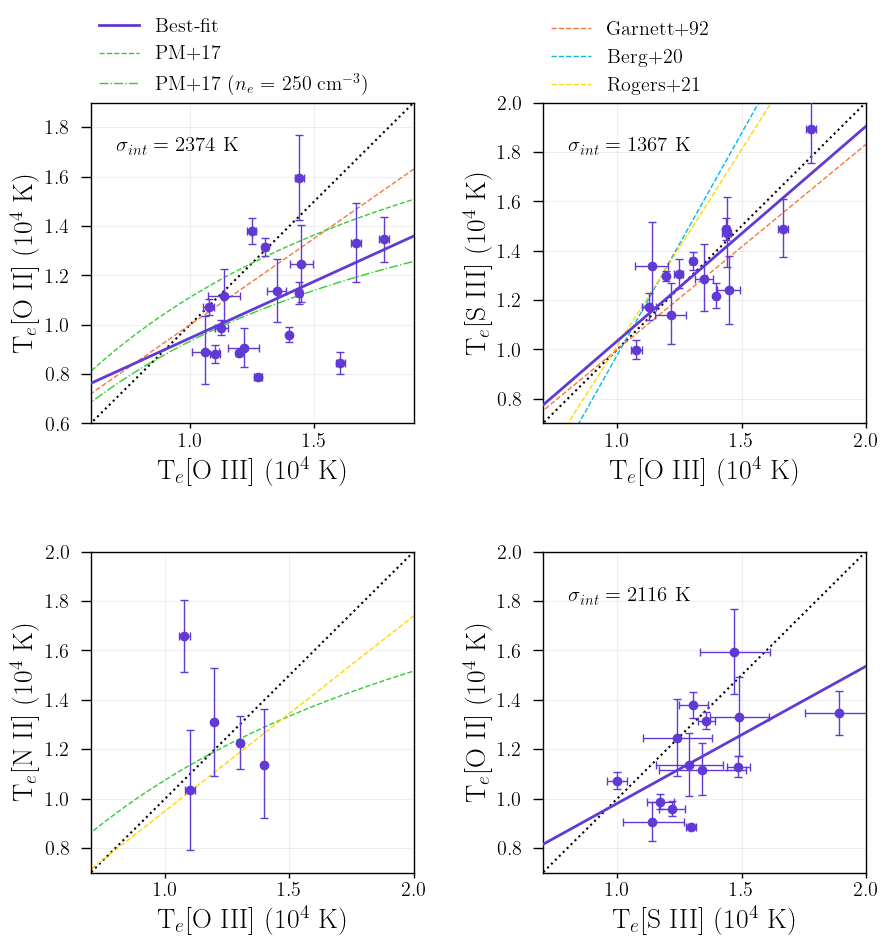

In [12]:
texPlot('on')
fig, axs = plt.subplots(2, 2)
fig.set_size_inches((10, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

# =================================================================
# T OII
# =================================================================

axs[0, 0].errorbar(tm_dict['tOIII'], tm_dict['tOII'],
               xerr=2*tOIII_error, yerr=2*tOII_error,
               marker='o', markersize=6, capsize=3, elinewidth=1,
               ls='', color=c[2], zorder=100)
axs[0, 0].plot(np.arange(0.5, 2.0, 0.1), np.arange(0.5, 2.0, 0.1),
            ls=':', color='black')
axs[0, 0].plot(np.arange(0.5, 5.0, 0.1), alpha_o3o2 + (np.arange(0.5, 5.0, 0.1) * beta_o3o2),
              color=c[2], lw=2, label='Best-fit', zorder=100)
#axs[0, 0].plot(np.arange(0.5, 5.0, 0.1), linear(np.arange(0.5, 5.0, 0.1), *cf_o3o2),
#              color='red', lw=2, label='curve-fit', zorder=100)

axs[0, 0].set_xlabel(r'T$_{e}$[O III] ($10^{4}$ K)')
axs[0, 0].set_ylabel(r'T$_{e}$[O II] ($10^{4}$ K)')
axs[0, 0].set_xlim(0.6, 1.9)
axs[0, 0].set_ylim(0.6, 1.9)
axs[0, 0].plot(G92('TO3', 'TO2')[0], G92('TO3', 'TO2')[1],
              ls='--', lw=1, color=cz[0])
axs[0, 0].plot(PM17('TO3', 'TO2')[0], PM17('TO3', 'TO2')[1],
              ls='--', lw=1, label='PM+17', color='limegreen')
axs[0, 0].plot(PM17_den(250)[0], PM17_den(250)[1],
              ls='-.', lw=1, color='limegreen', label='PM+17 ($n_{e}$ = 250 cm$^{-3}$)')
axs[0, 0].text(0.7, 1.7, s=r'$\sigma_{int} =$ '+str(round(upy.nominal_values(sig_int_o3o2)*10000))+' K', fontsize=15)
axs[0, 0].legend(loc=(0.0, 1.0))

# =================================================================
# T SIII
# =================================================================

axs[0, 1].errorbar(tm_dict['tOIII'], tm_dict['tSIII'],
               xerr=2*tOIII_error, yerr=2*tSIII_error,
               marker='o', markersize=6, capsize=3, elinewidth=1,
               ls='', color=c[2], zorder=100)
axs[0, 1].plot(np.arange(0.5, 2.5, 0.1), np.arange(0.5, 2.5, 0.1),
            ls=':', color='black')
axs[0, 1].plot(np.arange(0.5, 5.0, 0.1), (beta_o3s3 * np.arange(0.5, 5.0, 0.1)) + alpha_o3s3,
              color=c[2], lw=2, zorder=100)
axs[0, 1].plot(G92('TO3', 'TS3')[0], G92('TO3', 'TS3')[1],
              ls='--', lw=1, color=cz[0], label='Garnett+92')
axs[0, 1].plot(B20('TO3', 'TS3')[0], B20('TO3', 'TS3')[1],
              ls='--', lw=1, label='Berg+20', color=c[0])
axs[0, 1].plot(R21('TO3', 'TS3')[0], R21('TO3', 'TS3')[1],
              ls='--', lw=1, color='gold', label='Rogers+21')
axs[0, 1].set_xlabel(r'T$_{e}$[O III] ($10^{4}$ K)')
axs[0, 1].set_ylabel(r'T$_{e}$[S III] ($10^{4}$ K)')
axs[0, 1].set_xlim(0.7, 2.0)
axs[0, 1].set_ylim(0.7, 2.0)
axs[0, 1].text(0.8, 1.8, s=r'$\sigma_{int} =$ '+str(round(upy.nominal_values(sig_int_o3s3)*10000))+' K', fontsize=15)
axs[0, 1].legend(loc=(0.0, 1.0))

# =================================================================
# T NII
# =================================================================

axs[1, 0].errorbar(tm_dict['tOIII'], tm_dict['tNII'],
               xerr=2*tOIII_error, yerr=2*tNII_error,
               marker='o', markersize=6, capsize=3, elinewidth=1,
               ls='', color=c[2], zorder=100)
axs[1, 0].plot(np.arange(0.0, 3.0, 0.1), np.arange(0.0, 3.0, 0.1),
            ls=':', color='black')
axs[1, 0].set_xlabel(r'T$_{e}$[O III] ($10^{4}$ K)')
axs[1, 0].set_ylabel(r'T$_{e}$[N II] ($10^{4}$ K)')
axs[1, 0].set_xlim(0.7, 2.0)
axs[1, 0].set_ylim(0.7, 2.0)
axs[1, 0].plot(PM17('TN2', 'TO3')[0], PM17('TN2', 'TO3')[1],
              ls='--', lw=1, color='limegreen')
axs[1, 0].plot(R21('TN2', 'TO3')[0], R21('TN2', 'TO3')[1],
              ls='--', lw=1, color='gold')

# =================================================================
# T OII vs T SIII
# =================================================================

axs[1, 1].errorbar(tm_dict['tSIII'], tm_dict['tOII'],
               xerr=2*tSIII_error, yerr=2*tOII_error,
               marker='o', markersize=6, capsize=3, elinewidth=1,
               ls='', color=c[2], zorder=100)
axs[1, 1].plot(np.arange(0.0, 3.0, 0.1), np.arange(0.0, 3.0, 0.1),
            ls=':', color='black')
axs[1, 1].plot(np.arange(0.5, 5.0, 0.1), (beta_s3o2 * np.arange(0.5, 5.0, 0.1)) + alpha_s3o2,
              color=c[2], lw=2, zorder=100)
axs[1, 1].set_xlabel(r'T$_{e}$[S III] ($10^{4}$ K)')
axs[1, 1].set_ylabel(r'T$_{e}$[O II] ($10^{4}$ K)')
axs[1, 1].set_xlim(0.7, 2.0)
axs[1, 1].set_ylim(0.7, 2.0)
axs[1, 1].text(0.8, 1.8, s=r'$\sigma_{int} =$ '+str(round(upy.nominal_values(sig_int_s3o2)*10000))+' K', fontsize=15)

axs[0, 0].grid(visible=True, alpha=0.2)
axs[0, 1].grid(visible=True, alpha=0.2)
axs[1, 0].grid(visible=True, alpha=0.2)
axs[1, 1].grid(visible=True, alpha=0.2)

#fig.savefig('./chapter4/temp_relations.pdf', bbox_inches='tight', facecolor='white')

In [13]:
print('Median of analogs')
print('============================')
print('T[OIII]:', np.median(upy.uarray(tm_dict['tOIII'], tOIII_error)))
print('T[OII]:', np.median(upy.uarray(tm_dict['tOII'], tOII_error)))
print('T[SIII]:', np.nanmedian(upy.uarray(tm_dict['tSIII'], tSIII_error)))
print('T[NII]:', np.nanmedian(upy.uarray(tm_dict['tNII'], tNII_error)))

Median of analogs
T[OIII]: 1.288+/-0.005
T[OII]: 1.094+/-0.027
T[SIII]: 1.301+/-0.016
T[NII]: 1.23+/-0.04


/home/benjamin/anaconda3/envs/analogs/lib/python3.9/site-packages/numpy/lib/function_base.py:2412: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)


In [14]:
print('Slope [OIII] vs [OII] fit: {:.2f}'.format(ufloat(beta_o3o2, beta_o3o2_std)))
print('Intercept [OIII] vs [OII] fit: {:.2f}'.format(ufloat(alpha_o3o2, alpha_o3o2_std)))

Slope [OIII] vs [OII] fit: 0.46+/-0.28
Intercept [OIII] vs [OII] fit: 0.49+/-0.38


In [15]:
print('Slope [OIII] vs [SIII] fit: {:.2f}'.format(ufloat(beta_o3s3, beta_o3s3_std)))
print('Intercept [OIII] vs [SIII] fit: {:.2f}'.format(ufloat(alpha_o3s3, alpha_o3s3_std)))

Slope [OIII] vs [SIII] fit: 0.87+/-0.20
Intercept [OIII] vs [SIII] fit: 0.17+/-0.28


In [16]:
print('Slope [SIII] vs [OII] fit: {:.2f}'.format(ufloat(beta_s3o2, beta_s3o2_std)))
print('Intercept [SIII] vs [OII] fit: {:.2f}'.format(ufloat(alpha_s3o2, alpha_s3o2_std)))

Slope [SIII] vs [OII] fit: 0.55+/-0.31
Intercept [SIII] vs [OII] fit: 0.43+/-0.41


# Densitiy dependence

Text(0.7, 0.65, '$n_{e}$ = 1000 cm$^{-3}$')

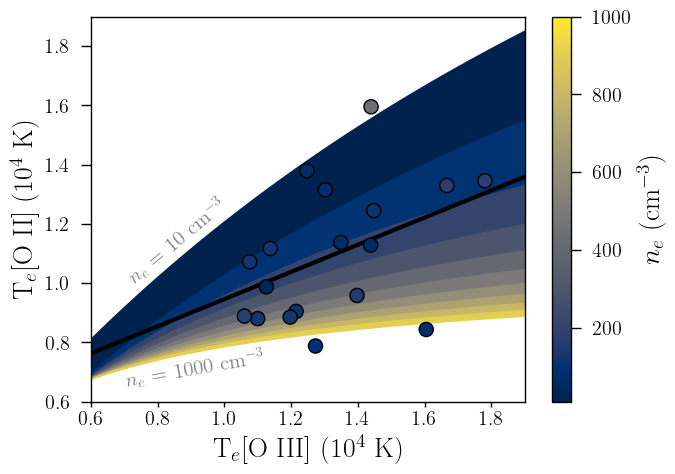

In [17]:
import matplotlib as mpl

# Select a color map
cmap = mpl.cm.cividis
dens_to_fill = np.array([10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
normalize = mpl.colors.Normalize(vmin=np.min(dens_to_fill), vmax=np.max(dens_to_fill))

texPlot('on')
fig, axs = plt.subplots(1, 1)
fig.set_size_inches((7, 5))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


axs.errorbar(tm_dict['tOIII'], tm_dict['tOII'],
               #xerr=2*tOIII_error, yerr=2*tOII_error,
               marker='', markersize=12, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='white', zorder=5)
sc = axs.scatter(tm_dict['tOIII'], tm_dict['tOII'],
                 edgecolor='black',
           s=104, c=tm_dict['ne'], vmin=10., vmax=1000, zorder=10, cmap='cividis')
#axs.plot(np.arange(0.5, 2.0, 0.1), np.arange(0.5, 2.0, 0.1),
#            ls=':', color='black')
plt.colorbar(sc, label=r'$n_{e}$ (cm$^{-3}$)')
axs.plot(np.arange(0.5, 5.0, 0.1), alpha_o3o2 + (np.arange(0.5, 5.0, 0.1) * beta_o3o2),
              color='black', lw=3, label='Best-fit')


#axs.fill_between(PM17_den(0)[0], PM17_den(0)[1], PM17_den(10)[1])

for i in range(len(dens_to_fill) - 1):
    axs.fill_between(PM17_den(dens_to_fill[i])[0],
                     PM17_den(dens_to_fill[i])[1], PM17_den(dens_to_fill[i+1])[1],
                     color=cmap(normalize(dens_to_fill[i])), zorder=0)

axs.set_xlim(0.6, 1.9)
axs.set_ylim(0.6, 1.9)
axs.set_xlabel(r'T$_{e}$[O III] ($10^{4}$ K)')
axs.set_ylabel(r'T$_{e}$[O II] ($10^{4}$ K)')

axs.text(0.7, 1.0, r'$n_{e}$ = 10 cm$^{-3}$', rotation=40, fontsize=15, alpha=0.5)
axs.text(0.7, 0.65, r'$n_{e}$ = 1000 cm$^{-3}$', rotation=10, fontsize=15, alpha=0.5)
#fig.savefig('./chapter5/temp_dens_dependence.pdf', bbox_inches='tight')

## Probing abundances from relations

In [18]:
# Measured chemical abundances
abundance_measured = pd.read_csv(magePath+'results/metals/abundance_measured_final.csv')

# Estimated chemical abundances from relations
abundance_estimated = pd.read_csv(magePath+'results/metals/abundance_estimated_final.csv')

In [19]:
log_OH_error = np.array(list(zip(abundance_measured['log_OH'] - abundance_measured['log_OH_16'],
                                 abundance_measured['log_OH_84'] - abundance_measured['log_OH']))).T

log_OH_G92_error = np.array(list(zip(abundance_estimated['log_OH_G92'] - abundance_estimated['log_OH_G92_16'],
                                     abundance_estimated['log_OH_G92_84'] - abundance_estimated['log_OH_G92']))).T

log_OH_tw_error = np.array(list(zip(abundance_estimated['log_OH_tw'] - abundance_estimated['log_OH_tw_16'],
                                    abundance_estimated['log_OH_tw_84'] - abundance_estimated['log_OH_tw']))).T

log_q_error = np.array(list(zip(abundance_measured['log_q'] - abundance_measured['log_q_16'],
                                abundance_measured['log_q_84'] - abundance_measured['log_q']))).T

Text(0.5, 0, '12 + log(O/H)$_{Direct}$')

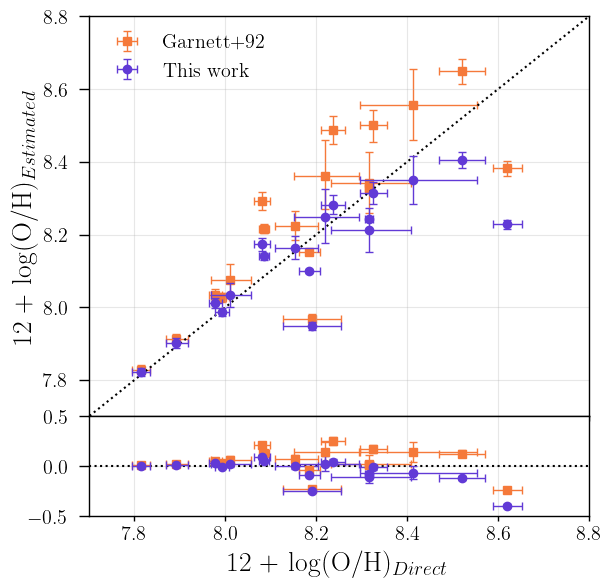

In [20]:
texPlot('on')
fig = plt.figure(1)
fig.set_size_inches(5, 5)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.grid(visible=True, alpha=0.3)
ax1.grid(visible=True, alpha=0.3)

ax.plot(np.arange(7.5, 9.5, 0.1), np.arange(7.5, 9.5, 0.1), color='black', ls=':')

ax.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_G92'],
            xerr=2*log_OH_error, yerr=2*log_OH_G92_error,
            marker='s', markersize=6, capsize=3,
            ls='', color=cz[0], elinewidth=1,
            label='Garnett+92', zorder=0)

ax.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_tw'],
            xerr=2*log_OH_error, yerr=2*log_OH_tw_error,
            marker='o', markersize=6, capsize=3, elinewidth=1,
            ls='', color=c[2], label='This work', zorder=5)

ax.set_xlim(7.7, 8.8)
ax1.set_xlim(7.7, 8.8)
ax.set_ylim(7.7, 8.8)
ax.set_xticklabels([])

ax1.axhline(0, color='black', ls=':')

ax1.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_G92'] - abundance_measured['log_OH'],
            xerr=2 * log_OH_error, yerr=2 * log_OH_G92_error,
            marker='s', markersize=6, capsize=3, elinewidth=1,
            ls='', color=cz[0], label='Garnett+92')

ax1.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_tw'] - abundance_measured['log_OH'],
            xerr=2 * log_OH_error, yerr=2 * log_OH_tw_error,
            marker='o', markersize=6, capsize=3, elinewidth=1,
            ls='', color=c[2], label='This work')
ax.legend()

ax1.set_ylim(-0.5, 0.5)

ax.set_ylabel(r'12 + log(O/H)$_{Estimated}$')
ax1.set_xlabel(r'12 + log(O/H)$_{Direct}$')

#ax.scatter(abundance_measured['log_OH'][7], abundance_estimated['log_OH_tw'][7], 
#          s=200, marker='*', color='black')

#fig.savefig('./chapter5/temprel_predictions.pdf', bbox_inches='tight')

In [21]:
print('Estimated scatter')
print('Linear fit:', round(np.std(abundance_estimated['log_OH_tw'] - abundance_measured['log_OH']), 4))
print('Garnett 1992:', round(np.std(abundance_estimated['log_OH_G92'] - abundance_measured['log_OH']), 4))
print('======================')
print('Mean difference')
print('Linear fit:', round(np.mean(np.abs(abundance_estimated['log_OH_tw'] - abundance_measured['log_OH'])), 4))
print('Garnett 1992:', round(np.mean(np.abs(abundance_estimated['log_OH_G92'] - abundance_measured['log_OH'])), 4))

Estimated scatter
Linear fit: 0.1143
Garnett 1992: 0.1248
Mean difference
Linear fit: 0.0775
Garnett 1992: 0.1096


In [22]:
real = []
est_tw = []
est_g92 = []
for i in range(len(abundance_measured['log_OH'])):
    if i == 6 or i == 7:
        continue
    else:
        real.append(abundance_measured['log_OH'][i])
        est_tw.append(abundance_estimated['log_OH_tw'][i])
        est_g92.append(abundance_estimated['log_OH_G92'][i])

In [23]:
print('Estimated scatter')
print('Linear fit:', round(np.std(np.array(est_tw) - np.array(real)), 4))
print('Garnett 1992:', round(np.std(np.array(est_g92) - np.array(real)), 4))

Estimated scatter
Linear fit: 0.059
Garnett 1992: 0.0778


In [24]:
0.11 - 0.078

0.032

# Physical conditions

In [25]:
# SED fitting results
sed_results = fits.open('/home/benjamin/Documents/sed_fitting/old_pop_late_burst/results.fits')
# To exclude the companion of J2212+0006
mask_sed = (sed_results[1].data['id'] != 'J2212+0006_comp')

# log(M*)
unc_m_star = upy.uarray(sed_results[1].data['bayes.stellar.m_star'],
                        sed_results[1].data['bayes.stellar.m_star_err'])[mask_sed]
m_star = upy.nominal_values(upy.log10(unc_m_star))
m_star_err = upy.std_devs(upy.log10(unc_m_star))

# log(SFR)
unc_sfr = upy.uarray(sed_results[1].data['bayes.sfh.sfr'],
                     sed_results[1].data['bayes.sfh.sfr_err'])[mask_sed]
sfr = upy.nominal_values(upy.log10(unc_sfr))
sfr_err = upy.std_devs(upy.log10(unc_sfr))

# To get E(B - V)
bal_dec = pd.read_csv('/home/benjamin/Documents/analogs/results/bal_decrements.csv')

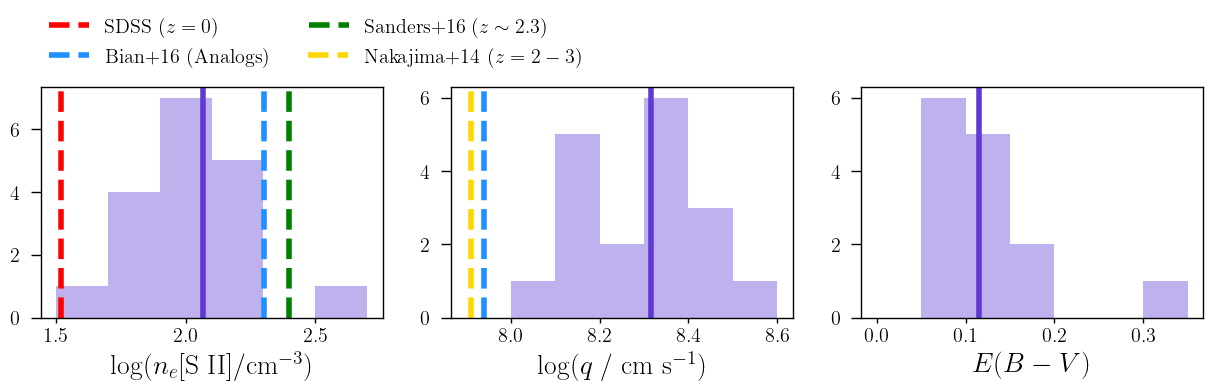

In [26]:
fig, axs = plt.subplots(1, 3)
fig.set_size_inches(15, 3)

# Electron density
axs[0].hist(np.log10(tm_dict['ne']), bins=np.arange(1.5, 2.8, 0.2), color=c[2], alpha=0.4)
axs[0].axvline(np.median(np.log10(tm_dict['ne'])), lw=4, color=c[2])
axs[0].axvline(np.log10(33), color='red', lw=4, ls='--', label=r'SDSS ($z = 0$)')
axs[0].axvline(np.log10(200), color='dodgerblue', lw=4, ls='--', label='Bian+16 (Analogs)')
axs[0].axvline(np.log10(250), color='green', lw=4, ls='--', label='Sanders+16 ($z \sim 2.3$)')
axs[0].set_xlabel(r'log($n_{e}$[S II]/cm$^{-3}$)')
axs[0].legend(ncols=2, loc=(0., 1.05))


# Ionization parameter
axs[1].hist(abundance_measured['log_q'], bins=np.arange(7.9, 8.7, 0.1), color=c[2], alpha=0.4)
axs[1].axvline(np.median(abundance_measured['log_q']), lw=4, color=c[2])
axs[1].axvline(7.94, color='dodgerblue', lw=4, ls='--')
axs[1].axvline(7.91, color='gold', lw=4, ls='--', label='Nakajima+14 ($z = 2 - 3$)')
axs[1].legend(loc=(-0.44, 1.05))
axs[1].set_xlabel(r'log($q$ / cm s$^{-1}$)')

# Color excess
axs[2].hist(bal_dec['E_BV'][bal_dec['E_BV'] > 0], bins=np.arange(0, 0.4, 0.05), color=c[2], alpha=0.4)
axs[2].axvline(np.median(bal_dec['E_BV'][bal_dec['E_BV'] > 0]), lw=4, color=c[2])
axs[2].set_xlabel('$E(B - V)$')
#fig.savefig(magePath+'analysis/chapter4/properties1.pdf', bbox_inches='tight')

In [27]:
print('Analogs Median values')
print('====================================')
print('Electron density:', np.median(upy.uarray(tm_dict['ne'], np.mean(ne_error, axis=0))))
print('log(ne):', np.median(upy.log10(upy.uarray(tm_dict['ne'], np.mean(ne_error, axis=0)))))
print('------------------------------------')
print('Ionization parameter')
print('log(q):', np.median(upy.uarray(abundance_measured['log_q'], np.mean(log_q_error, axis=0))))
print('------------------------------------')
print('E(B-V):', np.median(upy.uarray(bal_dec['E_BV'][bal_dec['E_BV'] > 0],
                                      bal_dec['E_BV_err'][bal_dec['E_BV'] > 0])))

Analogs Median values
Electron density: 117+/-22
log(ne): 2.07+/-0.08
------------------------------------
Ionization parameter
log(q): 8.315+/-0.007
------------------------------------
E(B-V): 0.115+/-0.033


In [28]:
def rodrigueiro2011(log_m):
    log_SFR = -6.42 + (log_m * 0.79)
    return log_SFR

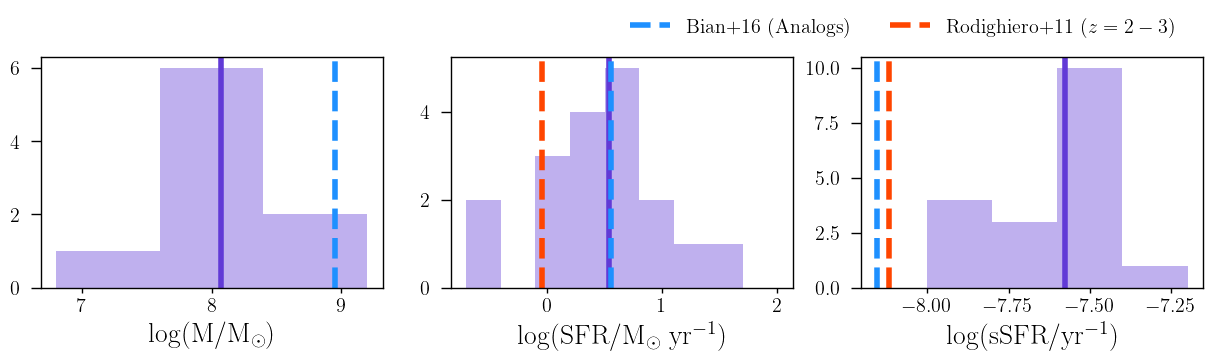

In [29]:
fig, axs = plt.subplots(1, 3)
fig.set_size_inches(15, 3)

# Stellar mass
axs[0].hist(m_star, bins=np.arange(6.8, 9.5, 0.4), color=c[2], alpha=0.4)
axs[0].axvline(np.median(m_star), lw=4, color=c[2])
axs[0].axvline(np.log10(9 * 1e8), color='dodgerblue', lw=4, ls='--', label='Bian+18 (Analogs)')
axs[0].set_xlabel(r'log(M/M$_{\odot}$)')

# SFR
axs[1].hist(sfr, bins=np.arange(-0.7, 2.0, 0.3), color=c[2], alpha=0.4)
axs[1].axvline(np.median(sfr), lw=4, color=c[2])
axs[1].axvline(np.log10(3.6), color='dodgerblue', lw=4, ls='--', label='Bian+16 (Analogs)')
axs[1].axvline(rodrigueiro2011(np.median(m_star)),
               color='orangered', lw=4, ls='--', label='Rodighiero+11 ($z = 2-3$)')
axs[1].set_xlabel(r'log(SFR/M$_{\odot}$ yr$^{-1}$)')

# sSFR
axs[2].hist(sfr - m_star, bins=np.arange(-8.0, -7.0, 0.2), color=c[2], alpha=0.4)
axs[2].axvline(np.median(sfr - m_star), lw=4, color=c[2])
axs[2].axvline(np.log10(7 * 1e-9), color='dodgerblue', lw=4, ls='--', label='Bian+16 (Analogs)')
axs[2].axvline(rodrigueiro2011(np.median(m_star)) - np.median(m_star),
               color='orangered', lw=4, ls='--', label='Rodighiero+11 ($z = 2-3$)')
axs[2].set_xlabel(r'log(sSFR/yr$^{-1}$)')
axs[2].legend(loc=(-0.7, 1.05), ncols=2)

#fig.savefig(magePath+'analysis/chapter4/properties2.pdf', bbox_inches='tight')

In [30]:
print('Analogs Median values')
print('====================================')
print('Stellar mass:', np.median(upy.uarray(m_star, m_star_err)))
print('log SFR:', np.median(upy.uarray(sfr, sfr_err)))
print('SFR:', np.median(10**(upy.uarray(sfr, sfr_err))))
print('log sSFR:', np.median(upy.uarray(sfr, sfr_err) - upy.uarray(m_star, m_star_err)))
print('log sSFR:', np.median(10**(upy.uarray(sfr, sfr_err) - upy.uarray(m_star, m_star_err))))

Analogs Median values
Stellar mass: 8.07+/-0.13
log SFR: 0.541+/-0.034
SFR: 3.50+/-0.29
log sSFR: -7.58+/-0.18
log sSFR: (2.7+/-1.1)e-08


In [34]:
-1.492 + (1.847 * 8.07) - (0.08026 * (8.07**2))

8.186365526

In [ ]:
12+log(O/H) = −1.492 + 1.847(logM∗) − 0.08026(logM∗)2

In [31]:
mu_06 = upy.uarray(m_star, m_star_err) - 0.6 * (upy.uarray(sfr, sfr_err) - 0.5)
y = mu_06 - 10
fmr_z = 8.80 + 0.188 * y - 0.220 * y**2 - 0.0531 * y**3

In [32]:
sed_results[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  655 / length of dimension 1                          
NAXIS2  =                   19 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                   81 / number of table fields                         
TTYPE1  = 'id      '                                                            
TFORM1  = '15A     '                                                            
TTYPE2  = 'bayes.attenuation.E_BVs'                                             
TFORM2  = 'D       '                                                            
TUNIT2  = 'mag     '        

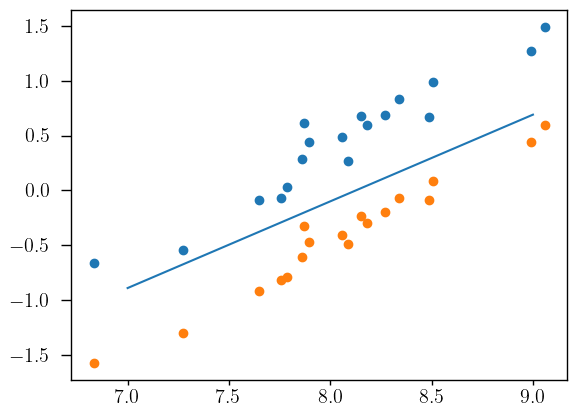

In [33]:
plt.scatter(m_star, sfr)
mass_range = np.linspace(7.0, 9.0, 100)
plt.plot(mass_range, rodrigueiro2011(mass_range))
plt.scatter(m_star, np.log10(sed_results[1].data['bayes.sfh.sfr100Myrs'][mask_sed]))

In [27]:
np.mean(np.abs(np.log10(sed_results[1].data['bayes.sfh.sfr100Myrs'][mask_sed]) - sfr))

0.8576741113535221

# ----------------------------------------

Text(0, 0.5, 'T[O III]')

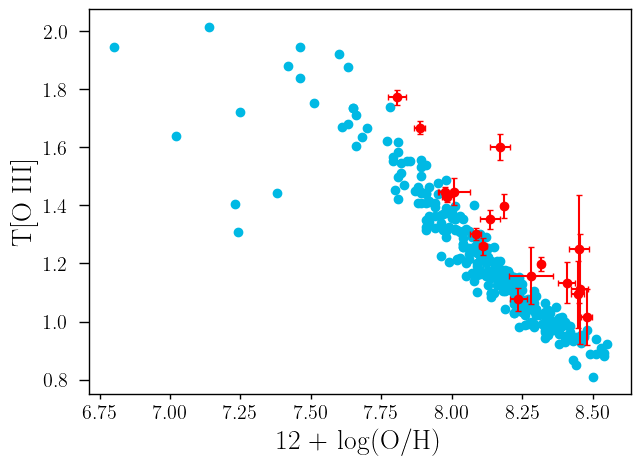

In [39]:
plt.figure(figsize=(7, 5))
plt.errorbar(abundance_measured['log_OH'], tm_dict['tOIII'],
             abundance_measured['log_OH_err'], tm_dict['tOIII_err'],
            ls='', marker='o', capsize=2, color='red')

plt.scatter(izotov['12+logO/H'], izotov['Te'], color=c[0])
plt.xlabel('12 + log(O/H)')
plt.ylabel('T[O III]')

# Densities

In [40]:
# Metallicities and ratios
total_temden = pd.read_csv(magePath+'results/metals/temden_lines.csv')

delta_O3O2 = upy.uarray(total_temden['ne_OIII'], total_temden['ne_OIII_err']) \
           - upy.uarray(total_temden['ne_OII'], total_temden['ne_OII_err'])
#delta_O3S2 = upy.uarray(total['ne_OIII'], total['ne_OIII_err']) - upy.uarray(total['ne_SII'], total['ne_SII_err'])

FileNotFoundError: [Errno 2] No such file or directory: '/home/benjamin/Documents/analogs/results/metals/temden_lines.csv'

In [ ]:
dO3O2_mean = upy.nominal_values(np.mean(delta_O3O2))
dO3O2_std = upy.std_devs(np.mean(delta_O3O2))
#O3S2_mean = upy.nominal_values(np.mean(delta_O3S2))
#dO3S2_std = upy.std_devs(np.mean(delta_O3S2))

In [99]:
sigma_ne_test = np.std(upy.nominal_values(delta_O3O2))
print('Scatter')
print('sigma =', round(sigma_ne_test, 2))

Scatter
sigma = 4.09


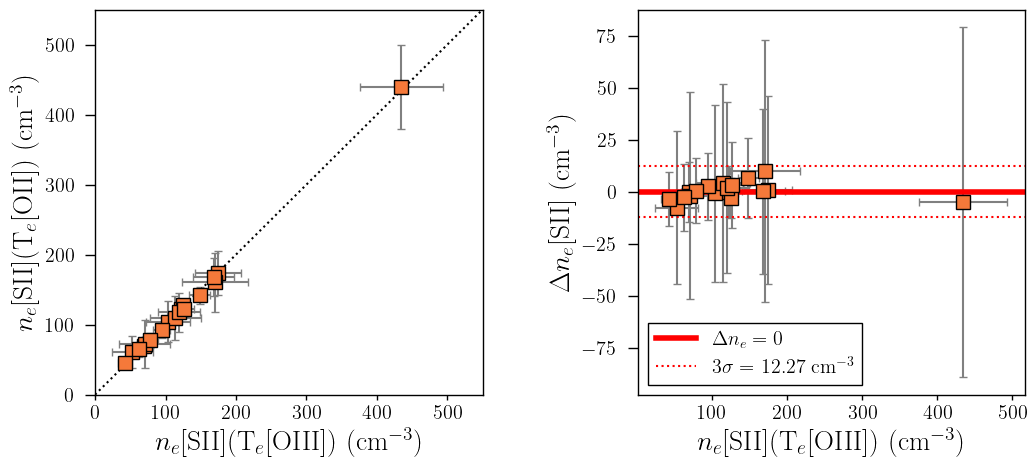

In [98]:
texPlot('on')
fig, axs = plt.subplots(1, 2)
fig.set_size_inches((12, 5))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

axs[0].errorbar(total_temden['ne_OIII'], total_temden['ne_OII'],
                   xerr = total_temden['ne_OIII_err'],
                   yerr = total_temden['ne_OII_err'],
                   marker='s', markersize=10, ls='', capsize=3,
                   ecolor='gray', color=cz[0], markeredgecolor='black')

axs[0].plot(np.arange(0.0, 600.0, 1), np.arange(0.0, 600.0, 1), ls=':', color='black')
axs[0].set_xlabel(r'$n_{e}$[SII](T$_{e}$[OIII]) (cm$^{-3}$)')
axs[0].set_ylabel(r'$n_{e}$[SII](T$_{e}$[OII]) (cm$^{-3}$)')
axs[0].set_xlim(0.0, 550.)
axs[0].set_ylim(0.0, 550.)

# Other comparison of the previous plot using the difference with the
# 1:1 relation
axs[1].errorbar(total_temden['ne_OIII'], upy.nominal_values(delta_O3O2),
                   xerr = total_temden['ne_OIII_err'],
                   yerr = upy.std_devs(delta_O3O2),
                   marker='s', markersize=10, ls='', markeredgecolor='black',
                   ecolor='gray', color=cz[0], capsize=3)
axs[1].axhline(0.0, lw=4, color='red', label='$\Delta n_{e} = 0$')
axs[1].axhline( 3*sigma_ne_test, ls=':', color='red', label='$3\sigma = $ '+str(round(3*sigma_ne_test, 2))+' cm$^{-3}$')
axs[1].axhline(-3*sigma_ne_test, ls=':', color='red')
axs[1].legend(frameon=True, framealpha=1, edgecolor='black', fancybox=False, loc='lower left')
axs[1].set_xlabel(r'$ n_{e}$[SII](T$_{e}$[OIII]) (cm$^{-3}$)')
axs[1].set_ylabel(r'$\Delta n_{e}$[SII] (cm$^{-3}$)')

fig.savefig('density_test.pdf', bbox_inches='tight')

In [97]:
os.getcwd()

'/home/benjamin/Documents/analogs/analysis'

In [4]:
# Temperatures
temden_measured = pd.read_csv(magePath+'results/metals/temden_measured.csv')
tm_dict = {}

In [5]:
for key in temden_measured.keys():
    tm_dict[key] = temden_measured[key].to_numpy()

In [5]:
dict_for_latex = final_temden.copy()
dict_for_latex['tOIII_nar_16'] = dict_for_latex['tOIII_nar'] - dict_for_latex['tOIII_nar_16']
dict_for_latex['tOIII_nar_84'] = dict_for_latex['tOIII_nar_84'] - dict_for_latex['tOIII_nar']

dict_for_latex['tOIII_brd_16'] = dict_for_latex['tOIII_brd'] - dict_for_latex['tOIII_brd_16']
dict_for_latex['tOIII_brd_84'] = dict_for_latex['tOIII_brd_84'] - dict_for_latex['tOIII_brd']

dict_for_latex['tOIII_tot_16'] = dict_for_latex['tOIII_tot'] - dict_for_latex['tOIII_tot_16']
dict_for_latex['tOIII_tot_84'] = dict_for_latex['tOIII_tot_84'] - dict_for_latex['tOIII_tot']

dict_for_latex['tOII_16'] = dict_for_latex['tOII'] - dict_for_latex['tOII_16']
dict_for_latex['tOII_84'] = dict_for_latex['tOII_84'] - dict_for_latex['tOII']

dict_for_latex['tNII_16'] = dict_for_latex['tNII'] - dict_for_latex['tNII_16']
dict_for_latex['tNII_84'] = dict_for_latex['tNII_84'] - dict_for_latex['tNII']

dict_for_latex['tSIII_16'] = dict_for_latex['tSIII'] - dict_for_latex['tSIII_16']
dict_for_latex['tSIII_84'] = dict_for_latex['tSIII_84'] - dict_for_latex['tSIII']


dict_for_latex['ne_16'] = dict_for_latex['ne'] - dict_for_latex['ne_16']
dict_for_latex['ne_84'] = dict_for_latex['ne_84'] - dict_for_latex['ne']

NameError: name 'final_temden' is not defined

In [ ]:
ra_h_for_table = []
dec_h_for_table = []
for galname in dict_for_latex['galname'].to_numpy():
    index = np.argmax(np.array(galnames) == galname)
    ra_h_for_table.append(ra_h[index])
    dec_h_for_table.append(dec_h[index])
    
dict_for_latex.insert(loc=1, column='RA', value=np.array(ra_h_for_table))
dict_for_latex.insert(loc=2, column='DEC', value=np.array(dec_h_for_table))

In [9]:
dict_for_latex.to_latex(float_format='{:.3f}'.format)

'\\begin{tabular}{llllrrrrrrrrrrrrrrrrrrrrr}\n\\toprule\n & galname & RA & DEC & tOIII_nar & tOIII_nar_16 & tOIII_nar_84 & tOIII_brd & tOIII_brd_16 & tOIII_brd_84 & tOIII_tot & tOIII_tot_16 & tOIII_tot_84 & tOII & tOII_16 & tOII_84 & ne & ne_16 & ne_84 & tNII & tNII_16 & tNII_84 & tSIII & tSIII_16 & tSIII_84 \\\\\n\\midrule\n0 & J0021 & 00:21:01.02 & +00:52:48.11 & 1.072 & 0.015 & 0.015 & 1.087 & 0.047 & 0.047 & 1.078 & 0.011 & 0.011 & 1.070 & 0.017 & 0.017 & 122.642 & 8.517 & 8.214 & 1.650 & 0.070 & 0.068 & 1.000 & 0.018 & 0.018 \\\\\n1 & J0023 & 00:23:39.61 & -09:48:48.72 & 1.293 & 0.010 & 0.010 & 0.854 & 0.240 & 0.199 & 1.269 & 0.010 & 0.010 & 1.197 & 0.022 & 0.022 & 68.850 & 9.590 & 9.689 & NaN & NaN & NaN & 1.379 & 0.027 & 0.028 \\\\\n2 & J0136 & 01:36:30.59 & -00:37:55.97 & 1.430 & 0.026 & 0.023 & 0.921 & 0.178 & 0.171 & 1.337 & 0.016 & 0.017 & 1.140 & 0.062 & 0.068 & 71.248 & 33.659 & 33.438 & NaN & NaN & NaN & 1.287 & 0.065 & 0.072 \\\\\n3 & J0240 & 02:40:52.19 & -08:28:27.41 &

In [6]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(temden_measured)

   galname  tOIII_nar  tOIII_nar_16  tOIII_nar_84  tOIII_brd  tOIII_brd_16   
0    J0021   1.073784      1.058581      1.088844   1.088638      1.041290  \
1    J0023   1.287796      1.277495      1.297553   0.850476      0.614050   
2    J0136   1.431770      1.405463      1.454797   0.921363      0.741405   
3    J0240   1.660021      1.644924      1.674604   1.107996      1.074844   
4    J0252        NaN           NaN           NaN        NaN           NaN   
5    J0305   1.215340      1.154476      1.273152   1.215703      1.070885   
6    J0950   1.312805      1.301512      1.324328   1.138696      1.104462   
7    J1146        NaN           NaN           NaN        NaN           NaN   
8    J1226   1.439646      1.436145      1.443159  -0.202033     -3.077215   
9    J1444   1.684171      1.671307      1.696866   1.429883      1.244276   
10   J1448   1.204419      1.200855      1.207852   1.011325      0.992642   
11   J1624   1.016400      0.970466      1.061070   1.913688    

In [7]:
tOIII_nar_error = np.array(list(zip(tm_dict['tOIII_nar'] - tm_dict['tOIII_nar_16'],
                                    tm_dict['tOIII_nar_84'] - tm_dict['tOIII_nar']))).T

tOIII_brd_error = np.array(list(zip(tm_dict['tOIII_brd'] - tm_dict['tOIII_brd_16'],
                                    tm_dict['tOIII_brd_84'] - tm_dict['tOIII_brd']))).T

tOIII_tot_error = np.array(list(zip(tm_dict['tOIII_tot'] - tm_dict['tOIII_tot_16'],
                                    tm_dict['tOIII_tot_84'] - tm_dict['tOIII_tot']))).T

tOII_error = np.array(list(zip(tm_dict['tOII'] - tm_dict['tOII_16'],
                               tm_dict['tOII_84'] - tm_dict['tOII']))).T

tNII_error = np.array(list(zip(tm_dict['tNII'] - tm_dict['tNII_16'],
                               tm_dict['tNII_84'] - tm_dict['tNII']))).T

tSIII_error = np.array(list(zip(tm_dict['tSIII'] - tm_dict['tSIII_16'],
                                tm_dict['tSIII_84'] - tm_dict['tSIII']))).T

ne_error = np.array(list(zip(tm_dict['ne'] - tm_dict['ne_16'],
                             tm_dict['ne_84'] - tm_dict['ne']))).T

In [8]:
# Masks to filter out bad values
mask_oiii = (tm_dict['tOIII_brd'] > 0.3)
#mask_nii = (ft_dict['tNII'] < 2.0)
#mask_siii = (ft_dict['tSIII'] < 2)

# T[OIII]

In [9]:
np.random.seed(999)

lm_o3_nar = linmix.LinMix(tm_dict['tOIII_tot'][mask_oiii], tm_dict['tOIII_nar'][mask_oiii],
                         tOIII_tot_error.mean(axis=0)[mask_oiii], tOIII_nar_error.mean(axis=0)[mask_oiii],
                         K=2)
lm_o3_nar.run_mcmc(silent=True)

In [10]:
np.random.seed(999)

lm_o3_brd = linmix.LinMix(tm_dict['tOIII_tot'][mask_oiii], tm_dict['tOIII_brd'][mask_oiii],
                       tOIII_tot_error.mean(axis=0)[mask_oiii], tOIII_brd_error.mean(axis=0)[mask_oiii],
                       K=2)
lm_o3_brd.run_mcmc(silent=True)

In [11]:
alpha_o3_nar = np.mean(lm_o3_nar.chain['alpha'])
alpha_o3_nar_std = np.std(lm_o3_nar.chain['alpha'])
beta_o3_nar = np.mean(lm_o3_nar.chain['beta'])
beta_o3_nar_std = np.std(lm_o3_nar.chain['beta'])
sig_int_nar_o3 = upy.sqrt(ufloat(np.mean(lm_o3_nar.chain['sigsqr']), np.std(lm_o3_nar.chain['sigsqr'])))

alpha_o3_brd = np.mean(lm_o3_brd.chain['alpha'])
alpha_o3_brd_std = np.std(lm_o3_brd.chain['alpha'])
beta_o3_brd = np.mean(lm_o3_brd.chain['beta'])
beta_o3_brd_std = np.std(lm_o3_brd.chain['beta'])
sig_int_brd_o3 = upy.sqrt(ufloat(np.mean(lm_o3_brd.chain['sigsqr']), np.std(lm_o3_brd.chain['sigsqr'])))

In [12]:
sig_int_nar_o3 * 10000

859.6939634184192+/-256.18851768046903

In [13]:
sig_int_brd_o3 * 10000

1468.1840856931767+/-614.7488198256341

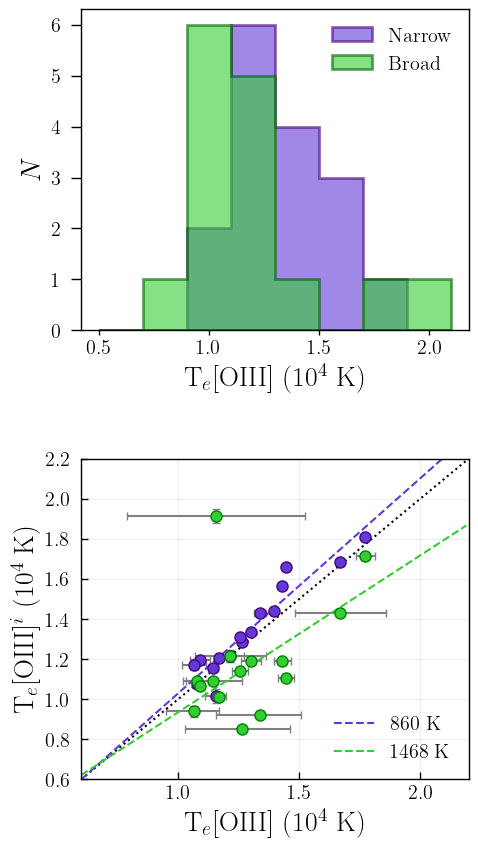

In [14]:
texPlot('on')
fig, axs = plt.subplots(2, 1)
fig.set_size_inches((5, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

axs[0].hist(tm_dict['tOIII_nar'], bins=np.arange(0.5, 2.3, 0.2),
            histtype='stepfilled', lw=2, alpha=0.6, edgecolor='indigo', color=c[2], label='Narrow')
axs[0].hist(tm_dict['tOIII_brd'], bins=np.arange(0.5, 2.3, 0.2),
            histtype='stepfilled', lw=2, alpha=0.6, edgecolor='darkgreen', color='limegreen', label='Broad')
axs[0].axvline(np.median(tm_dict['tOIII_nar']), ls='--', color='purple')
axs[0].axvline(np.median(tm_dict['tOIII_brd']), ls='--', color='darkgreen')
axs[0].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')
axs[0].set_ylabel(r'$N$')
axs[0].legend()



axs[1].errorbar(tm_dict['tOIII_tot'], tm_dict['tOIII_nar'],
             tOIII_tot_error, tOIII_nar_error,
             fmt='o', ls='', markeredgecolor='indigo',
             ecolor='gray', capsize=3, markersize=8, color=c[2])
axs[1].errorbar(tm_dict['tOIII_tot'], tm_dict['tOIII_brd'],
             tOIII_tot_error, tOIII_brd_error,
             fmt='o', ls='', markeredgecolor='green',
             ecolor='gray', capsize=3, markersize=8, color='limegreen')
axs[1].plot(np.arange(0.6, 2.2, 0.01), np.arange(0.6, 2.2, 0.01), ls=':', color='black')
axs[1].plot(np.arange(0.6, 2.2, 0.01), (beta_o3_nar * np.arange(0.6, 2.2, 0.01)) + alpha_o3_nar,
           ls='--', color=c[2],
           label=str(round(upy.nominal_values(sig_int_nar_o3)*10000))+' K')
axs[1].plot(np.arange(0.6, 2.2, 0.01), (beta_o3_brd * np.arange(0.6, 2.2, 0.01)) + alpha_o3_brd,
           ls='--', color='limegreen',
           label=str(round(upy.nominal_values(sig_int_brd_o3)*10000))+' K')
axs[1].set_xlim(0.6, 2.2)
axs[1].set_ylim(0.6, 2.2)
axs[1].tick_params(direction='in', length=5)
axs[1].grid(visible=True, alpha=0.2)
axs[1].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')
axs[1].set_ylabel(r'T$_{e}$[OIII]$^{i}$ ($10^{4}$ K)')
axs[1].legend()
#fig.savefig('./tOIII.pdf', bbox_inches='tight', facecolor='white');

In [15]:
print('Slope Narrow fit: {:.2f}'.format(ufloat(beta_o3_nar, beta_o3_nar_std)))
print('Intercept Narrow fit: {:.2f}'.format(ufloat(alpha_o3_nar, alpha_o3_nar_std)))

Slope Narrow fit: 1.07+/-0.12
Intercept Narrow fit: -0.04+/-0.15


In [16]:
print('Slope Broad fit: {:.2f}'.format(ufloat(beta_o3_brd, beta_o3_brd_std)))
print('Intercept Broad fit: {:.2f}'.format(ufloat(alpha_o3_brd, alpha_o3_brd_std)))

Slope Broad fit: 0.78+/-0.22
Intercept Broad fit: 0.15+/-0.28


In [17]:
print('Median narrow: {:.2f}'.format(ufloat(np.median(tm_dict['tOIII_nar'][mask_oiii]), np.mean(np.mean(tOIII_nar_error, axis=0)[mask_oiii]))))
print('Median broad: {:.2f}'.format(ufloat(np.median(tm_dict['tOIII_brd'][mask_oiii]), np.mean(np.mean(tOIII_brd_error, axis=0)[mask_oiii]))))
print('Median total: {:.2f}'.format(ufloat(np.median(tm_dict['tOIII_tot'][mask_oiii]), np.mean(np.mean(tOIII_tot_error, axis=0)[mask_oiii]))))

Median narrow: 1.29+/-0.02
Median broad: 1.11+/-0.11
Median total: 1.26+/-0.01


In [18]:
print('Median [OII]: {:.2f}'.format(ufloat(np.median(tm_dict['tOII']), np.mean(np.mean(tOII_error, axis=0)))))
print('Median [NII]: {:.2f}'.format(ufloat(np.nanmedian(tm_dict['tNII']), np.nanmean(np.mean(tNII_error, axis=0)))))
print('Median [SIII]: {:.2f}'.format(ufloat(np.nanmedian(tm_dict['tSIII']), np.nanmean(np.mean(tSIII_error, axis=0)))))

Median [OII]: 1.07+/-0.04
Median [NII]: 1.23+/-0.09
Median [SIII]: 1.32+/-0.04


# Temperature relations

# Linear 

In [19]:
np.random.seed(999)

lm_o3s3 = linmix.LinMix(tm_dict['tOIII_tot'][~np.isnan(tm_dict['tSIII'])], tm_dict['tSIII'][~np.isnan(tm_dict['tSIII'])],
                       tOIII_tot_error.mean(axis=0)[~np.isnan(tm_dict['tSIII'])], tSIII_error.mean(axis=0)[~np.isnan(tm_dict['tSIII'])],
                       K=2)
lm_o3s3.run_mcmc(silent=True)

In [20]:
np.random.seed(999)

lm_o3o2 = linmix.LinMix(tm_dict['tOIII_tot'], tm_dict['tOII'],
                       tOIII_tot_error.mean(axis=0), tOII_error.mean(axis=0),
                       K=2)
lm_o3o2.run_mcmc(silent=True)

In [21]:
np.random.seed(999)

lm_s3o2 = linmix.LinMix(tm_dict['tSIII'][~np.isnan(tm_dict['tSIII'])], tm_dict['tOII'][~np.isnan(tm_dict['tSIII'])],
                       tSIII_error.mean(axis=0)[~np.isnan(tm_dict['tSIII'])], tOII_error.mean(axis=0)[~np.isnan(tm_dict['tSIII'])],
                       K=2)
lm_s3o2.run_mcmc(silent=True)

In [22]:
alpha_o3s3 = np.mean(lm_o3s3.chain['alpha'])
alpha_o3s3_std = np.std(lm_o3s3.chain['alpha'])
beta_o3s3 = np.mean(lm_o3s3.chain['beta'])
beta_o3s3_std = np.std(lm_o3s3.chain['beta'])
sig_int_o3s3 = upy.sqrt(ufloat(np.mean(lm_o3s3.chain['sigsqr']),
                                np.std(lm_o3s3.chain['sigsqr'])))

alpha_o3o2 = np.mean(lm_o3o2.chain['alpha'])
alpha_o3o2_std = np.std(lm_o3o2.chain['alpha'])
beta_o3o2 = np.mean(lm_o3o2.chain['beta'])
beta_o3o2_std = np.std(lm_o3o2.chain['beta'])
sig_int_o3o2 = upy.sqrt(ufloat(np.mean(lm_o3o2.chain['sigsqr']),
                                np.std(lm_o3o2.chain['sigsqr'])))

alpha_s3o2 = np.mean(lm_s3o2.chain['alpha'])
alpha_s3o2_std = np.std(lm_s3o2.chain['alpha'])
beta_s3o2 = np.mean(lm_s3o2.chain['beta'])
beta_s3o2_std = np.std(lm_s3o2.chain['beta'])
sig_int_s3o2 = upy.sqrt(ufloat(np.mean(lm_s3o2.chain['sigsqr']),
                                np.std(lm_s3o2.chain['sigsqr'])))

In [23]:
sig_int_o3s3 * 10000

1601.5302817851561+/-553.9469447568026

In [24]:
sig_int_o3o2 * 10000

2063.4682428030637+/-480.4548810626471

In [25]:
sig_int_s3o2 * 10000

1822.5038270300763+/-592.222311573715

# Non-linear functional form

In [31]:
params_o2o3 = Parameters()

params_o2o3.add('u', value=2.0)
params_o2o3.add('v', value=0.8)

def residuals_o2o3(params_o2o3, x, data, uncertainty):
    
    u = params_o2o3['u']
    v = params_o2o3['v']
    
    x = ft_dict['tOIII_tot']
    
    model = u / ((x**-1) + v)
    
    return (model - ft_dict['tOII']) / 0.036

In [32]:
np.random.seed(999)
out_fit_o2o3 = minimize(residuals_o2o3, params_o2o3, args=(1, 1, 1),
                       method='emcee', burn=1000, steps=2500)

100%|██████████████████████████████████████| 2500/2500 [00:10<00:00, 243.74it/s]


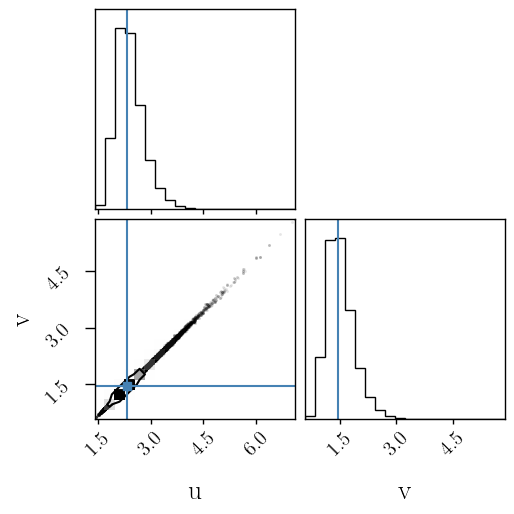

In [33]:
corner.corner(out_fit_o2o3.flatchain, labels=out_fit_o2o3.var_names,
             truths=list(out_fit_o2o3.params.valuesdict().values()));

In [34]:
u = out_fit_o2o3.flatchain.u.mean()
u_std = out_fit_o2o3.flatchain.u.std()

v = out_fit_o2o3.flatchain.v.mean()
v_std = out_fit_o2o3.flatchain.v.std()

In [35]:
print('TO2 = '+str(ufloat(u, u_std))+' / (TO3^-1 + '+str(ufloat(v, v_std))+')')

TO2 = 2.4+/-0.4 / (TO3^-1 + 1.5+/-0.4)


# Polynomial

In [36]:
params_poly_o2o3 = Parameters()

#params_poly_o2o3.add('a0', value=1.0)
params_poly_o2o3.add('a1', value=1.0)
params_poly_o2o3.add('a2', value=1.0)
params_poly_o2o3.add('a3', value=1.0)
#params_poly_o2o3.add('a4', value=1.0)
params_poly_o2o3.add('a5', value=1.0)

def residuals_poly_o2o3(params_poly_o2o3, x, data, uncertainty):
    
    #a0 = params_poly_o2o3['a0']
    a1 = params_poly_o2o3['a1']
    a2 = params_poly_o2o3['a2']
    a3 = params_poly_o2o3['a3']
    #a4 = params_poly_o2o3['a4']
    a5 = params_poly_o2o3['a5']
    
    x = ft_dict['tOIII_tot']
    
    #model = a0 + (a1 * x) + (a2 * (x**2)) + (a3 * (x**3)) + (a4 + (x**4)) + (a5 * (x**5))
    model = (a1 * x) + (a2 * (x**2)) + (a3 * (x**3)) + (a5 * (x**5))
    
    return (model - ft_dict['tOII']) / 0.036

In [37]:
np.random.seed(999)
out_poly_fit_o2o3 = minimize(residuals_poly_o2o3, params_poly_o2o3, args=(1, 1, 1),
                       method='emcee', burn=1000, steps=2500)

100%|██████████████████████████████████████| 2500/2500 [00:11<00:00, 209.01it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [103.77514116 108.03263257 113.14954874  50.86920764]


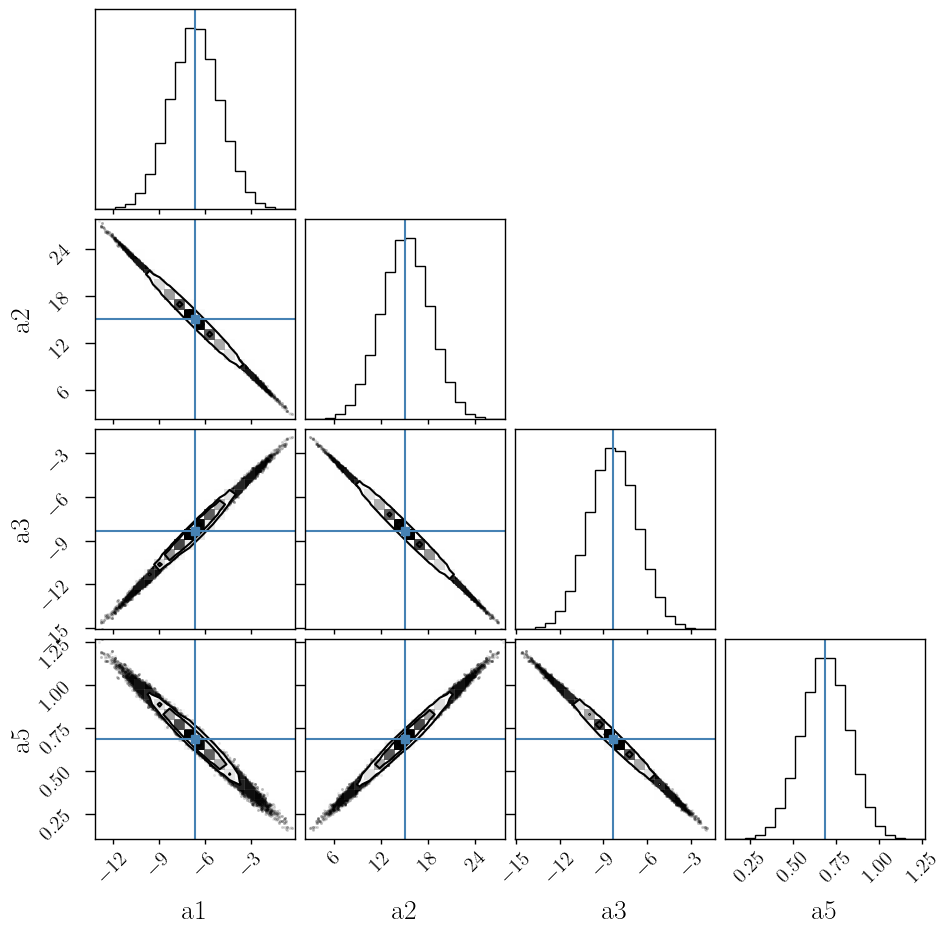

In [38]:
corner.corner(out_poly_fit_o2o3.flatchain, labels=out_poly_fit_o2o3.var_names,
             truths=list(out_poly_fit_o2o3.params.valuesdict().values()));

In [39]:
#a0 = out_poly_fit_o2o3.flatchain.a0.mean()
#a0_std = out_poly_fit_o2o3.flatchain.a0.std()

a1 = out_poly_fit_o2o3.flatchain.a1.mean()
a1_std = out_poly_fit_o2o3.flatchain.a1.std()

a2 = out_poly_fit_o2o3.flatchain.a2.mean()
a2_std = out_poly_fit_o2o3.flatchain.a2.std()

a3 = out_poly_fit_o2o3.flatchain.a3.mean()
a3_std = out_poly_fit_o2o3.flatchain.a3.std()

#a4 = out_poly_fit_o2o3.flatchain.a4.mean()
#a4_std = out_poly_fit_o2o3.flatchain.a4.std()

a5 = out_poly_fit_o2o3.flatchain.a5.mean()
a5_std = out_poly_fit_o2o3.flatchain.a5.std()

In [40]:
print('TO2 = ('+str(ufloat(a1, a1_std))+' * TO3)')
print('+ ('+str(ufloat(a2, a2_std))+' * TO3^2)')
print('+ ('+str(ufloat(a3, a3_std))+' * TO3^3)')
print('+ ('+str(ufloat(a5, a5_std))+' * TO3^5)')

TO2 = (-6.6+/-1.6 * TO3)
+ (15.1+/-3.1 * TO3^2)
+ (-8.3+/-1.7 * TO3^3)
+ (0.69+/-0.14 * TO3^5)


# Square root form

In [41]:
params_sqrt_o2o3 = Parameters()

params_sqrt_o2o3.add('y', value=0.8)
params_sqrt_o2o3.add('z', value=0.8)

def residuals_sqrt_o2o3(params_sqrt_o2o3, x, data, uncertainty):
    
    y = params_sqrt_o2o3['y']
    z = params_sqrt_o2o3['z']
    
    x = ft_dict['tOIII_tot']
    
    model = y  + (z * np.sqrt(x))
    
    return (model - ft_dict['tOII']) / 0.036

In [42]:
np.random.seed(999)
out_sqrt_fit_o2o3 = minimize(residuals_sqrt_o2o3, params_sqrt_o2o3, args=(1, 1, 1),
                       method='emcee', burn=1000, steps=2500)

100%|██████████████████████████████████████| 2500/2500 [00:09<00:00, 256.61it/s]


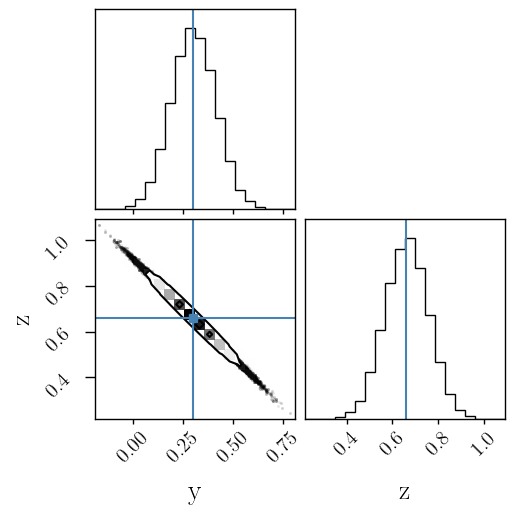

In [43]:
corner.corner(out_sqrt_fit_o2o3.flatchain, labels=out_sqrt_fit_o2o3.var_names,
             truths=list(out_sqrt_fit_o2o3.params.valuesdict().values()));

In [44]:
y = out_sqrt_fit_o2o3.flatchain.y.mean()
y_std = out_sqrt_fit_o2o3.flatchain.y.std()

z = out_sqrt_fit_o2o3.flatchain.z.mean()
z_std = out_sqrt_fit_o2o3.flatchain.z.std()

In [45]:
print('TO2 = '+str(ufloat(y, y_std))+' + '+str(ufloat(z, z_std))+' * sqrt(TO3)')

TO2 = 0.30+/-0.11 + 0.66+/-0.10 * sqrt(TO3)


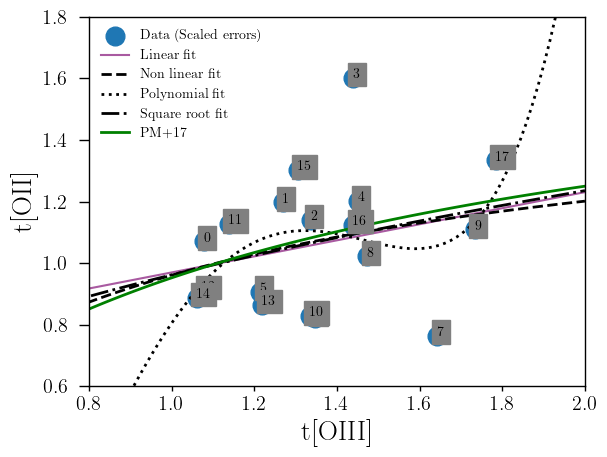

In [83]:
TFIT = u / ((np.linspace(0.6, 2.0, 100)**-1) + v)
TFIT_poly =  (a1 * np.linspace(0.6, 2.0, 100)) + (a2 * (np.linspace(0.6, 2.0, 100)**2)) + (a3 * (np.linspace(0.6, 2.0, 100)**3)) \
           + (a5 * (np.linspace(0.6, 2.0, 100)**5))
TFIT_sqrt = y + (z * np.sqrt(np.linspace(0.6, 2.0, 100)))

plt.scatter(ft_dict['tOIII_tot'], ft_dict['tOII'], s=5e3 * np.mean(np.mean(tOII_error, axis=0)),
           label='Data (Scaled errors)')
plt.plot(np.linspace(0.6, 2.0, 100), (beta_o3o2 * np.linspace(0.6, 2.0, 100)) + alpha_o3o2,
              color=cz[1], label='Linear fit')
plt.plot(np.linspace(0.6, 2.0, 100), TFIT, color='black', lw=2, ls='--',
         label='Non linear fit')
plt.plot(np.linspace(0.6, 2.0, 100), TFIT_poly, color='black', lw=2, ls=':',
         label='Polynomial fit')
plt.plot(np.linspace(0.6, 2.0, 100), TFIT_sqrt, color='black', lw=2, ls='-.',
         label='Square root fit')
plt.plot(np.linspace(0.6, 2.0, 100), 2 / (np.linspace(0.6, 2.0, 100)**-1 + 1.1), color='green', lw=2,
        label='PM+17')

#plt.scatter(ft_dict['tOIII_tot'][mask_bad_night], ft_dict['tOII'][mask_bad_night], s=10)

for i in range(len(ft_dict['galname'])):
    plt.text(ft_dict['tOIII_tot'][i], ft_dict['tOII'][i], i, fontsize=10, backgroundcolor='gray')

plt.xlabel('t[OIII]')
plt.ylabel('t[OII]')
plt.legend(fontsize=10)
plt.xlim(0.8, 2.0)
plt.ylim(0.6, 1.8)

plt.savefig('./temp_fit.pdf', bbox_inches='tight')

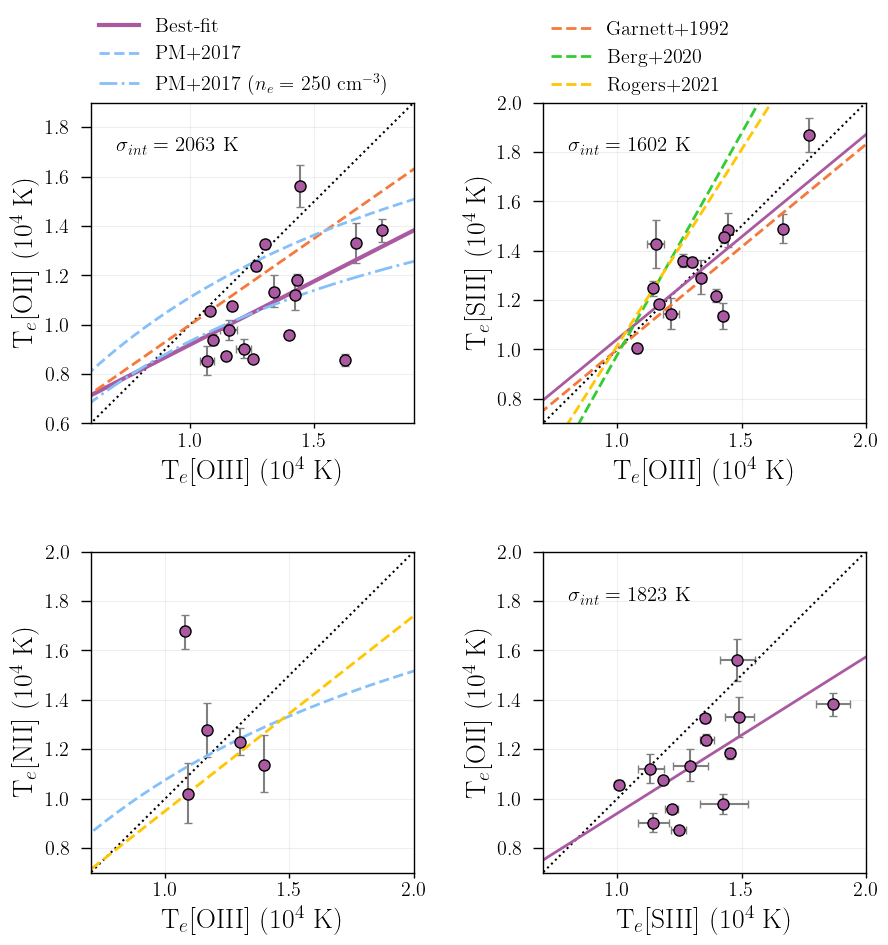

In [26]:
texPlot('on')
fig, axs = plt.subplots(2, 2)
fig.set_size_inches((10, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


axs[0, 0].errorbar(tm_dict['tOIII_tot'], tm_dict['tOII'],
               xerr=tOIII_tot_error, yerr=tOII_error,
               marker='o', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black')

axs[0, 0].plot(np.arange(0.5, 2.0, 0.1), np.arange(0.5, 2.0, 0.1),
            ls=':', color='black')
#axs[0, 0].plot(np.arange(0.5, 5.0, 0.1), u / ((np.arange(0.5, 5.0, 0.1)**-1) + v),
#              color=cz[1], lw=3, label='Best-fit')

axs[0, 0].plot(np.arange(0.5, 5.0, 0.1), alpha_o3o2 + (np.arange(0.5, 5.0, 0.1) * beta_o3o2),
              color=cz[1], lw=3, label='Best-fit')

axs[0, 0].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')
axs[0, 0].set_ylabel(r'T$_{e}$[OII] ($10^{4}$ K)')
axs[0, 0].set_xlim(0.6, 1.9)
axs[0, 0].set_ylim(0.6, 1.9)
axs[0, 0].plot(G92('TO3', 'TO2')[0], G92('TO3', 'TO2')[1],
              ls='--', lw=2, color=cz[0])
axs[0, 0].plot(PM17('TO3', 'TO2')[0], PM17('TO3', 'TO2')[1],
              ls='--', lw=2, label='PM+2017', color=cz[2])
axs[0, 0].plot(PM17_den(250)[0], PM17_den(250)[1],
              ls='-.', lw=2, color=cz[2], label='PM+2017 ($n_{e}$ = 250 cm$^{-3}$)')
axs[0, 0].text(0.7, 1.7, s=r'$\sigma_{int} =$ '+str(round(upy.nominal_values(sig_int_o3o2)*10000))+' K', fontsize=15)
axs[0, 0].legend(loc=(0.0, 1.0))



axs[0, 1].errorbar(tm_dict['tOIII_tot'], tm_dict['tSIII'],
               xerr=tOIII_tot_error, yerr=tSIII_error,
               marker='o', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black')
axs[0, 1].plot(np.arange(0.5, 2.5, 0.1), np.arange(0.5, 2.5, 0.1),
            ls=':', color='black')
axs[0, 1].plot(np.arange(0.5, 5.0, 0.1), (beta_o3s3 * np.arange(0.5, 5.0, 0.1)) + alpha_o3s3,
              color=cz[1], lw=2)
axs[0, 1].plot(G92('TO3', 'TS3')[0], G92('TO3', 'TS3')[1],
              ls='--', lw=2, color=cz[0], label='Garnett+1992')
axs[0, 1].plot(B20('TO3', 'TS3')[0], B20('TO3', 'TS3')[1],
              ls='--', lw=2, label='Berg+2020', color='limegreen')
axs[0, 1].plot(R21('TO3', 'TS3')[0], R21('TO3', 'TS3')[1],
              ls='--', lw=2, color=c[3], label='Rogers+2021')
axs[0, 1].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')
axs[0, 1].set_ylabel(r'T$_{e}$[SIII] ($10^{4}$ K)')
axs[0, 1].set_xlim(0.7, 2.0)
axs[0, 1].set_ylim(0.7, 2.0)
axs[0, 1].text(0.8, 1.8, s=r'$\sigma_{int} =$ '+str(round(upy.nominal_values(sig_int_o3s3)*10000))+' K', fontsize=15)
axs[0, 1].legend(loc=(0.0, 1.0))



axs[1, 0].errorbar(tm_dict['tOIII_tot'], tm_dict['tNII'],
               xerr=tOIII_tot_error, yerr=tNII_error,
               marker='o', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black')
axs[1, 0].plot(np.arange(0.0, 3.0, 0.1), np.arange(0.0, 3.0, 0.1),
            ls=':', color='black')
axs[1, 0].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')
axs[1, 0].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[1, 0].set_xlim(0.7, 2.0)
axs[1, 0].set_ylim(0.7, 2.0)
axs[1, 0].plot(PM17('TN2', 'TO3')[0], PM17('TN2', 'TO3')[1],
              ls='--', lw=2, color=cz[2])
axs[1, 0].plot(R21('TN2', 'TO3')[0], R21('TN2', 'TO3')[1],
              ls='--', lw=2, color=c[3])


axs[1, 1].errorbar(tm_dict['tSIII'], tm_dict['tOII'],
               xerr=tSIII_error, yerr=tOII_error,
               marker='o', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black')
axs[1, 1].plot(np.arange(0.0, 3.0, 0.1), np.arange(0.0, 3.0, 0.1),
            ls=':', color='black')
axs[1, 1].plot(np.arange(0.5, 5.0, 0.1), (beta_s3o2 * np.arange(0.5, 5.0, 0.1)) + alpha_s3o2,
              color=cz[1], lw=2)
axs[1, 1].set_xlabel(r'T$_{e}$[SIII] ($10^{4}$ K)')
axs[1, 1].set_ylabel(r'T$_{e}$[OII] ($10^{4}$ K)')
axs[1, 1].set_xlim(0.7, 2.0)
axs[1, 1].set_ylim(0.7, 2.0)
axs[1, 1].text(0.8, 1.8, s=r'$\sigma_{int} =$ '+str(round(upy.nominal_values(sig_int_s3o2)*10000))+' K', fontsize=15)

axs[0, 0].grid(visible=True, alpha=0.2)
axs[0, 1].grid(visible=True, alpha=0.2)
axs[1, 0].grid(visible=True, alpha=0.2)
axs[1, 1].grid(visible=True, alpha=0.2)

#fig.savefig('./t_t_relations.pdf', bbox_inches='tight', facecolor='white')

# Densitiy dependence

Text(0, 0.5, 'T$_{e}$[OII] ($10^{4}$ K)')

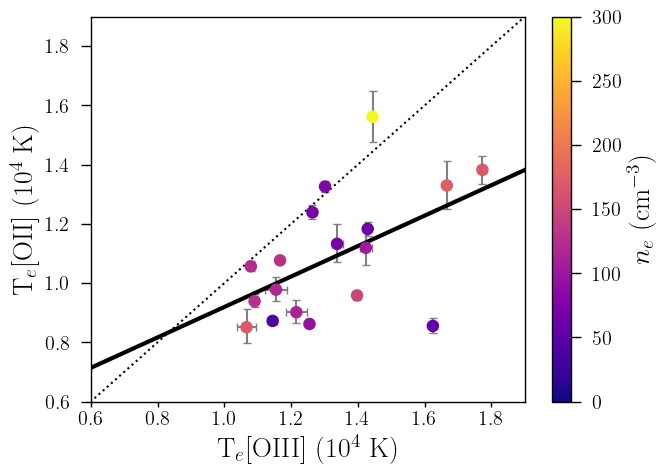

In [27]:
texPlot('on')
fig, axs = plt.subplots(1, 1)
fig.set_size_inches((7, 5))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


axs.errorbar(tm_dict['tOIII_tot'], tm_dict['tOII'],
               xerr=tOIII_tot_error, yerr=tOII_error,
               marker='', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black', zorder=0)
sc = axs.scatter(tm_dict['tOIII_tot'], tm_dict['tOII'],
           s=64, c=tm_dict['ne'], vmin=0., vmax=300, zorder=5, cmap='plasma')
axs.plot(np.arange(0.5, 2.0, 0.1), np.arange(0.5, 2.0, 0.1),
            ls=':', color='black')
#axs[0, 0].plot(np.arange(0.5, 5.0, 0.1), u / ((np.arange(0.5, 5.0, 0.1)**-1) + v),
#              color=cz[1], lw=3, label='Best-fit')
plt.colorbar(sc, label=r'$n_{e}$ (cm$^{-3}$)')
axs.plot(np.arange(0.5, 5.0, 0.1), alpha_o3o2 + (np.arange(0.5, 5.0, 0.1) * beta_o3o2),
              color='black', lw=3, label='Best-fit')

axs.set_xlim(0.6, 1.9)
axs.set_ylim(0.6, 1.9)
axs.set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')
axs.set_ylabel(r'T$_{e}$[OII] ($10^{4}$ K)')

In [28]:
print('Slope [OIII] vs [OII] fit: {:.2f}'.format(ufloat(beta_o3o2, beta_o3o2_std)))
print('Intercept [OIII] vs [OII] fit: {:.2f}'.format(ufloat(alpha_o3o2, alpha_o3o2_std)))

Slope [OIII] vs [OII] fit: 0.51+/-0.25
Intercept [OIII] vs [OII] fit: 0.41+/-0.33


In [29]:
print('Slope [OIII] vs [SIII] fit: {:.2f}'.format(ufloat(beta_o3s3, beta_o3s3_std)))
print('Intercept [OIII] vs [SIII] fit: {:.2f}'.format(ufloat(alpha_o3s3, alpha_o3s3_std)))

Slope [OIII] vs [SIII] fit: 0.83+/-0.24
Intercept [OIII] vs [SIII] fit: 0.21+/-0.32


In [30]:
print('Slope [SIII] vs [OII] fit: {:.2f}'.format(ufloat(beta_s3o2, beta_s3o2_std)))
print('Intercept [SIII] vs [OII] fit: {:.2f}'.format(ufloat(alpha_s3o2, alpha_s3o2_std)))

Slope [SIII] vs [OII] fit: 0.63+/-0.27
Intercept [SIII] vs [OII] fit: 0.31+/-0.36


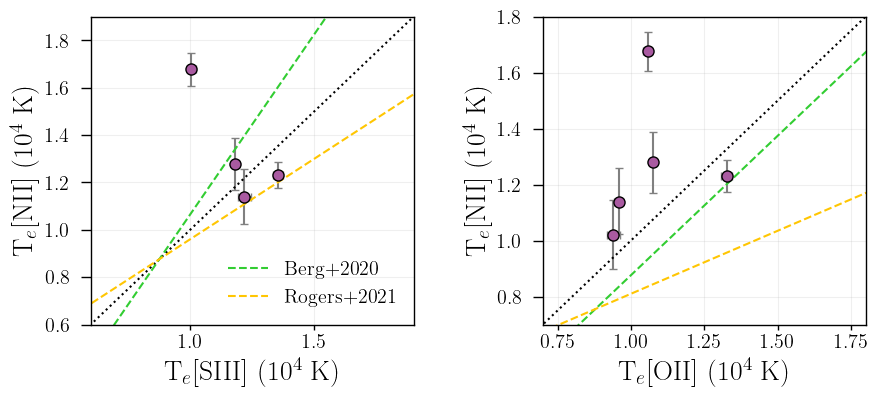

In [31]:
texPlot('on')
fig, axs = plt.subplots(1, 2)
fig.set_size_inches((10, 4))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


axs[0].errorbar(tm_dict['tSIII'], tm_dict['tNII'],
               xerr=tSIII_error, yerr=tNII_error,
               marker='o', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black')
axs[0].plot(np.arange(0.5, 2.0, 0.1), np.arange(0.5, 2.0, 0.1),
            ls=':', color='black')
axs[0].set_xlabel(r'T$_{e}$[SIII] ($10^{4}$ K)')
axs[0].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[0].set_xlim(0.6, 1.9)
axs[0].set_ylim(0.6, 1.9)
axs[0].plot(B20('TN2', 'TS3')[0], B20('TN2', 'TS3')[1],
              ls='--', label='Berg+2020', color='limegreen')
axs[0].plot(R21('TN2', 'TS3')[0], R21('TN2', 'TS3')[1],
              ls='--', label='Rogers+2021', color=c[3])
axs[0].grid(visible=True, alpha=0.2)
axs[0].legend()

axs[1].errorbar(tm_dict['tOII'], tm_dict['tNII'],
               xerr=tOII_error, yerr=tNII_error,
               marker='o', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black')
axs[1].plot(np.arange(0.5, 2.5, 0.1), np.arange(0.5, 2.5, 0.1),
            ls=':', color='black')
axs[1].set_xlabel(r'T$_{e}$[OII] ($10^{4}$ K)')
axs[1].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[1].set_xlim(0.7, 1.8)
axs[1].set_ylim(0.7, 1.8)
axs[1].plot(B20('TN2', 'TO2')[0], B20('TN2', 'TO2')[1],
              ls='--', label='Berg+2020', color='limegreen')
axs[1].plot(R21('TN2', 'TO2')[0], R21('TN2', 'TO2')[1],
              ls='--', label='Rogers+2021', color=c[3])
axs[1].grid(visible=True, alpha=0.2)

#fig.savefig('./nii_relations.pdf', bbox_inches='tight', facecolor='white');

In [32]:
print('Median ne: {:.2f}'.format(ufloat(np.median(tm_dict['ne']), np.mean(np.median(ne_error, axis=0)))))

Median ne: 116.68+/-22.61


## Probing abundances from relations

In [33]:
# Measured chemical abundances
abundance_measured = pd.read_csv(magePath+'results/metals/abundance_measured.csv')

# Estimated chemical abundances from relations
abundance_estimated = pd.read_csv(magePath+'results/metals/abundance_estimated.csv')

In [34]:
log_OH_error = np.array(list(zip(abundance_measured['log_OH'] - abundance_measured['log_OH_16'],
                                 abundance_measured['log_OH_84'] - abundance_measured['log_OH']))).T

log_OH_G92_error = np.array(list(zip(abundance_estimated['log_OH_G92'] - abundance_estimated['log_OH_G92_16'],
                                     abundance_estimated['log_OH_G92_84'] - abundance_estimated['log_OH_G92']))).T

log_OH_lin_error = np.array(list(zip(abundance_estimated['log_OH_lin'] - abundance_estimated['log_OH_lin_16'],
                                     abundance_estimated['log_OH_lin_84'] - abundance_estimated['log_OH_lin']))).T

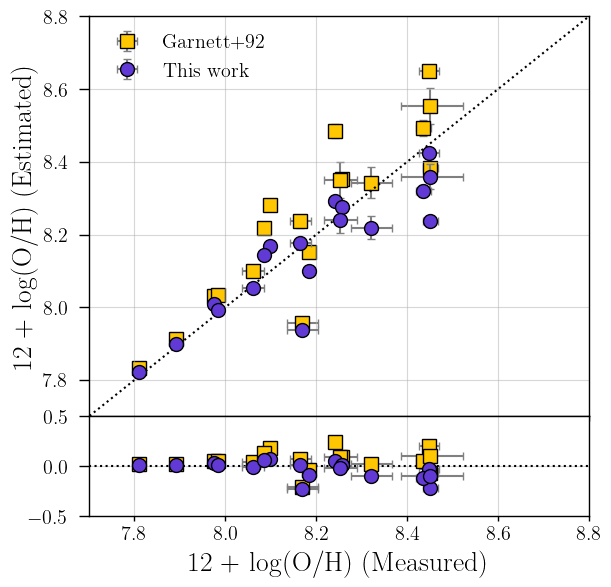

In [35]:
texPlot('on')
fig = plt.figure(1)
fig.set_size_inches(5, 5)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.grid(visible=True, alpha=0.5)
ax1.grid(visible=True, alpha=0.5)

ax.plot(np.arange(7.5, 9.5, 0.1), np.arange(7.5, 9.5, 0.1), color='black', ls=':')

ax.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_G92'],
            xerr=log_OH_error, yerr=log_OH_G92_error,
            marker='s', markersize=10, capsize=3,
            ls='', ecolor='gray', color=c[3],
            markeredgecolor='black', label='Garnett+92', zorder=0)

ax.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_lin'],
            xerr=log_OH_error, yerr=log_OH_lin_error,
            marker='o', markersize=10, capsize=3,
            ls='', ecolor='gray', color=c[2],
            markeredgecolor='black', label='This work', zorder=5)

ax.set_xlim(7.7, 8.8)
ax1.set_xlim(7.7, 8.8)
ax.set_ylim(7.7, 8.8)
ax.set_xticklabels([])

ax1.axhline(0, color='black', ls=':')

ax1.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_G92'] - abundance_measured['log_OH'],
            xerr=log_OH_error, yerr=log_OH_G92_error,
            marker='s', markersize=10, capsize=3,
            ls='', ecolor='gray', color=c[3],
            markeredgecolor='black', label='Garnett+92')

ax1.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_lin'] - abundance_measured['log_OH'],
            xerr=log_OH_error, yerr=log_OH_lin_error,
            marker='o', markersize=10, capsize=3,
            ls='', ecolor='gray', color=c[2],
            markeredgecolor='black', label='This work')
ax.legend()

ax1.set_ylim(-0.5, 0.5)

ax.set_ylabel('12 + log(O/H) (Estimated)')
ax1.set_xlabel('12 + log(O/H) (Measured)')

#for i in range(len(abundance_measured['galname'])):
#    ax.text(abundance_measured['log_OH'][i], abundance_estimated['log_OH_lin'][i],
#            abundance_estimated['galname'][i], fontsize=10, backgroundcolor='gray', 
#           rotation=45)
fig.savefig('new_OH_plot.pdf', bbox_inches='tight')

In [36]:
print('Estimated scatter')
print('Linear fit:', round(np.std(abundance_estimated['log_OH_lin'] - abundance_measured['log_OH']), 4))
print('Garnett 1992:', round(np.std(abundance_estimated['log_OH_G92'] - abundance_measured['log_OH']), 4))

Estimated scatter
Linear fit: 0.0857
Garnett 1992: 0.1006


In [37]:
round(0.1006 - 0.0857, 3)

0.015

(0.6, 1.9)

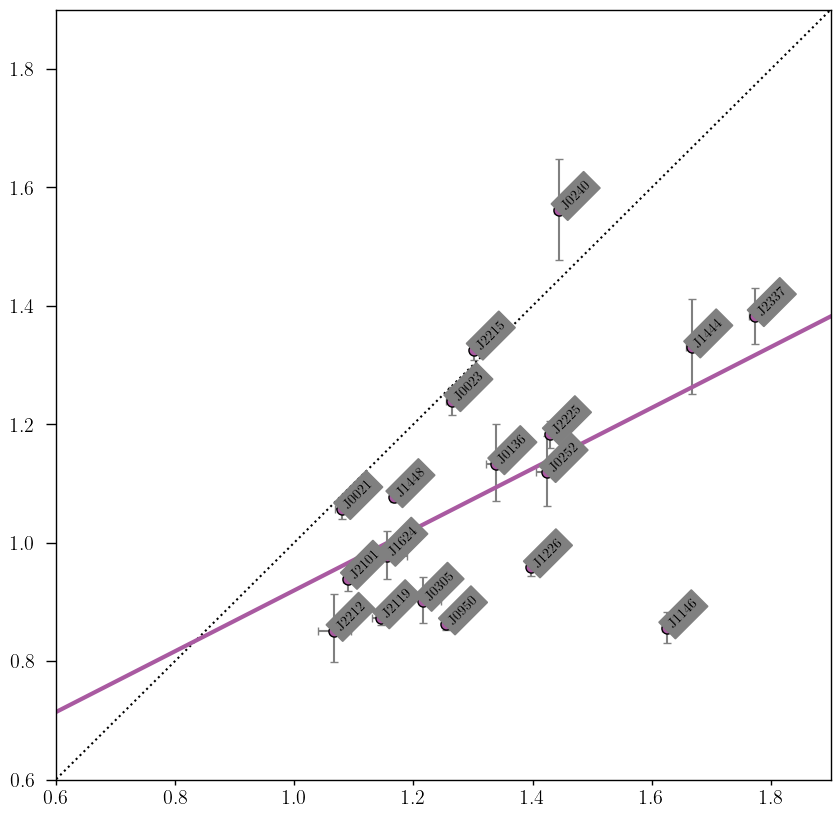

In [38]:
texPlot('on')
fig, axs = plt.subplots(1, 1)
fig.set_size_inches((10, 10))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


axs.errorbar(tm_dict['tOIII_tot'], tm_dict['tOII'],
               xerr=tOIII_tot_error, yerr=tOII_error,
               marker='o', markersize=8, capsize=3,
               ls='', ecolor='gray', color=cz[1],
                markeredgecolor='black')
axs.plot(np.arange(0.5, 2.0, 0.1), np.arange(0.5, 2.0, 0.1),
            ls=':', color='black')
#axs[0, 0].plot(np.arange(0.5, 5.0, 0.1), u / ((np.arange(0.5, 5.0, 0.1)**-1) + v),
#              color=cz[1], lw=3, label='Best-fit')

axs.plot(np.arange(0.5, 5.0, 0.1), alpha_o3o2 + (np.arange(0.5, 5.0, 0.1) * beta_o3o2),
              color=cz[1], lw=3, label='Best-fit')

for i in range(len(temden_measured['galname'])):
    axs.text(temden_measured['tOIII_tot'][i], temden_measured['tOII'][i],
            temden_measured['galname'][i], fontsize=10, backgroundcolor='gray', 
           rotation=45)
    
axs.set_xlim(0.6, 1.9)
axs.set_ylim(0.6, 1.9)

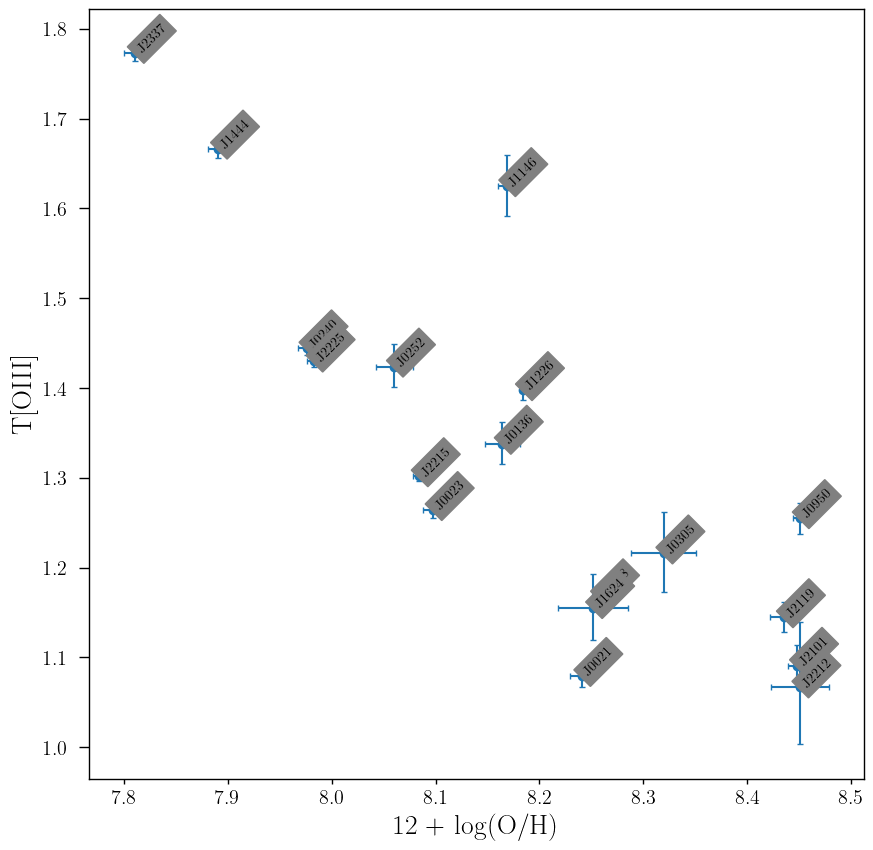

In [39]:
plt.figure(figsize=(10, 10))
plt.errorbar(abundance_measured['log_OH'], tm_dict['tOIII_tot'],
             log_OH_error, tOIII_tot_error,
            ls='', marker='o', capsize=2)
plt.xlabel('12 + log(O/H)')
plt.ylabel('T[OIII]')

for i in range(len(abundance_measured['galname'])):
    plt.text(abundance_measured['log_OH'][i], temden_measured['tOIII_tot'][i],
            abundance_estimated['galname'][i], fontsize=10, backgroundcolor='gray', 
           rotation=45)

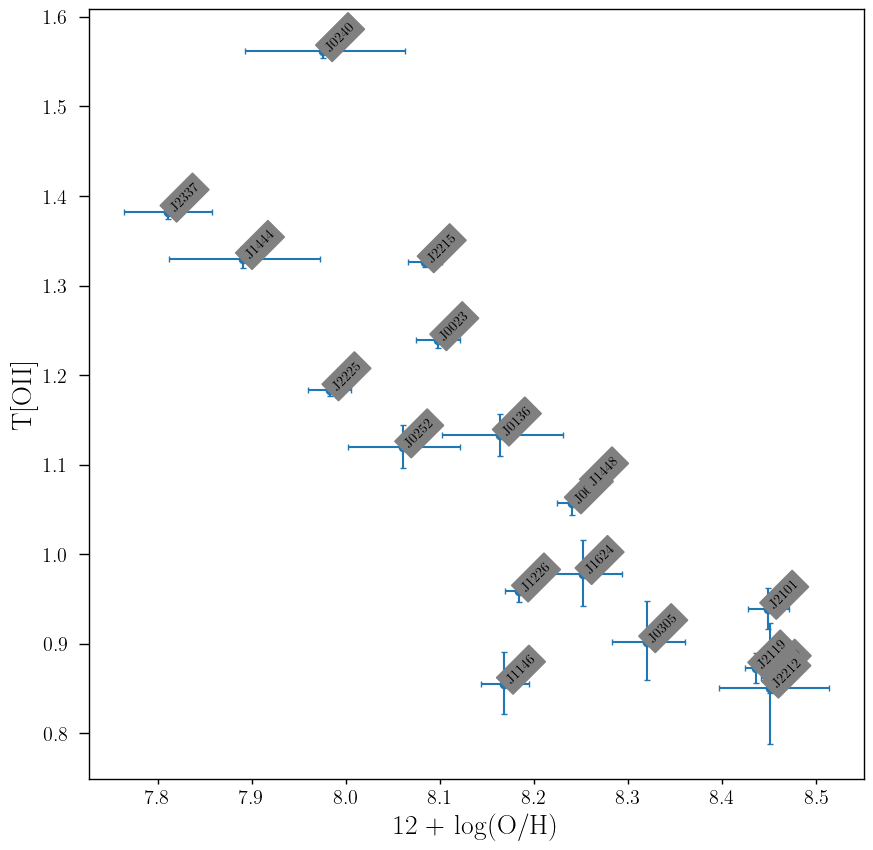

In [40]:
plt.figure(figsize=(10, 10))
plt.errorbar(abundance_measured['log_OH'], tm_dict['tOII'],
             log_OH_error, tOII_error,
            ls='', marker='o', capsize=2)
plt.xlabel('12 + log(O/H)')
plt.ylabel('T[OII]')

for i in range(len(abundance_measured['galname'])):
    plt.text(abundance_measured['log_OH'][i], temden_measured['tOII'][i],
            abundance_estimated['galname'][i], fontsize=10, backgroundcolor='gray', 
           rotation=45)

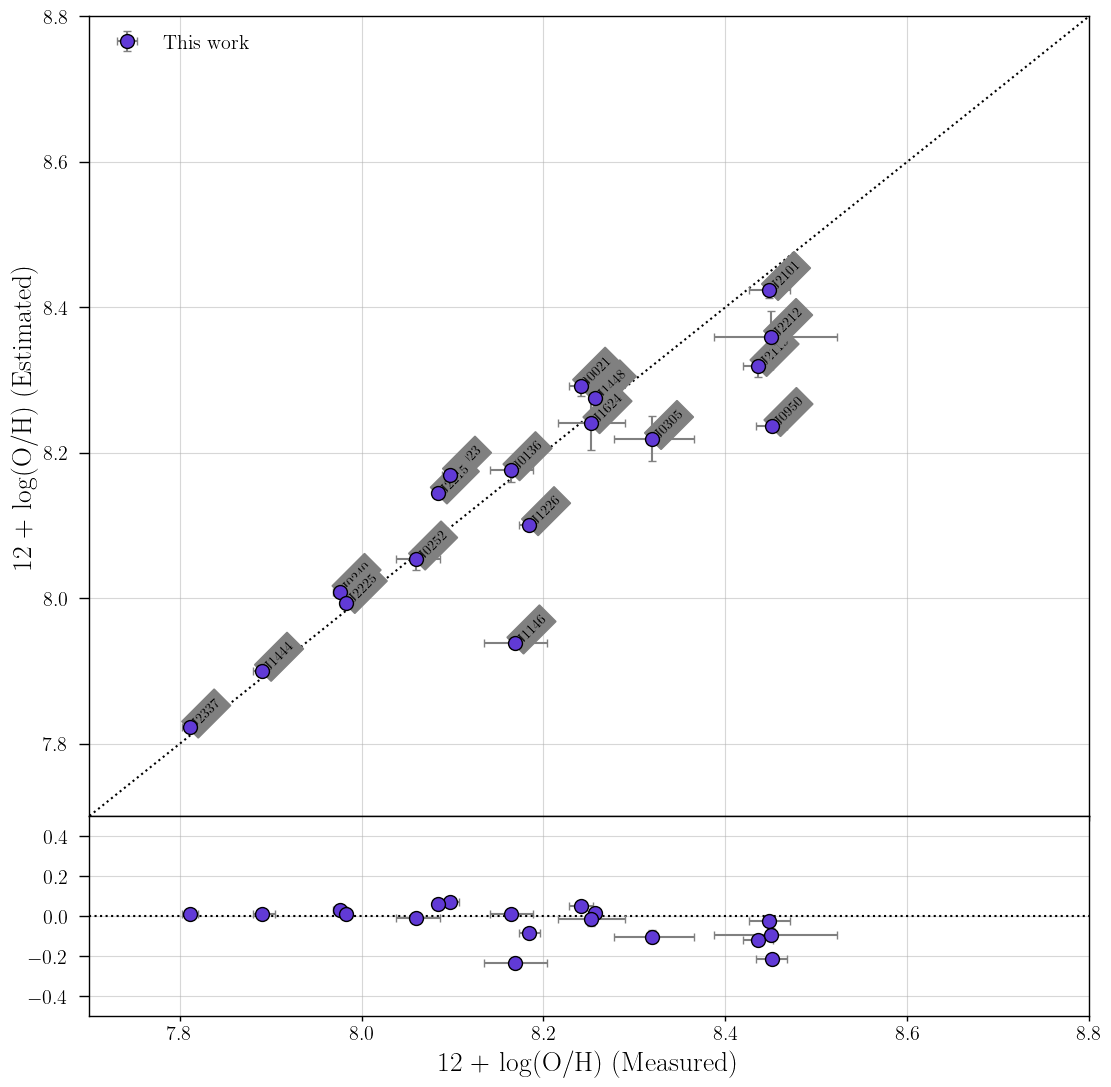

In [41]:
texPlot('on')
fig = plt.figure(1)
fig.set_size_inches(10, 10)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.grid(visible=True, alpha=0.5)
ax1.grid(visible=True, alpha=0.5)

ax.plot(np.arange(7.5, 9.5, 0.1), np.arange(7.5, 9.5, 0.1), color='black', ls=':')

#ax.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_G92'],
#            xerr=log_OH_error, yerr=log_OH_G92_error,
#            marker='s', markersize=10, capsize=3,
#            ls='', ecolor='gray', color=c[3],
#            markeredgecolor='black', label='Garnett+92', zorder=0)

ax.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_lin'],
            xerr=log_OH_error, yerr=log_OH_lin_error,
            marker='o', markersize=10, capsize=3,
            ls='', ecolor='gray', color=c[2],
            markeredgecolor='black', label='This work', zorder=5)

ax.set_xlim(7.7, 8.8)
ax1.set_xlim(7.7, 8.8)
ax.set_ylim(7.7, 8.8)
ax.set_xticklabels([])

ax1.axhline(0, color='black', ls=':')

#ax1.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_G92'] - abundance_measured['log_OH'],
#            xerr=log_OH_error, yerr=log_OH_G92_error,
#            marker='s', markersize=10, capsize=3,
#            ls='', ecolor='gray', color=c[3],
#            markeredgecolor='black', label='Garnett+92')

ax1.errorbar(abundance_measured['log_OH'], abundance_estimated['log_OH_lin'] - abundance_measured['log_OH'],
            xerr=log_OH_error, yerr=log_OH_lin_error,
            marker='o', markersize=10, capsize=3,
            ls='', ecolor='gray', color=c[2],
            markeredgecolor='black', label='This work')
ax.legend()

ax1.set_ylim(-0.5, 0.5)

ax.set_ylabel('12 + log(O/H) (Estimated)')
ax1.set_xlabel('12 + log(O/H) (Measured)')

for i in range(len(abundance_measured['galname'])):
    ax.text(abundance_measured['log_OH'][i], abundance_estimated['log_OH_lin'][i],
            abundance_estimated['galname'][i], fontsize=10, backgroundcolor='gray', 
           rotation=45)

In [53]:
abundances_final = pd.read_csv(magePath+'results/metals/abundance_final2.csv')
abun_dict = {}

for key in abun_final.keys():
    abun_dict[key] = abun_final[key].to_numpy()

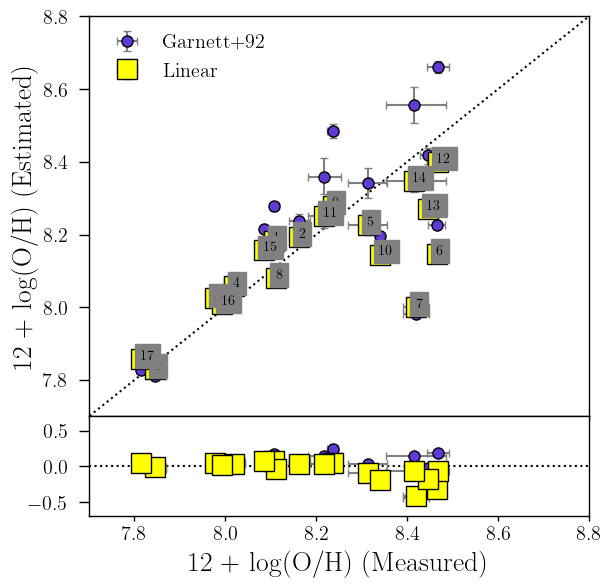

In [91]:
texPlot('on')
fig = plt.figure(1)
fig.set_size_inches(5, 5)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(np.arange(7.5, 9.5, 0.1), np.arange(7.5, 9.5, 0.1), color='black', ls=':')

ax.errorbar(abun_dict['log_OH'], abun_dict['log_OH_G92'],
            xerr=log_OH_error, yerr=log_OH_G92_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=c[2],
            markeredgecolor='black', label='Garnett+92')

ax.errorbar(abun_dict['log_OH'], abun_dict['log_OH_lin'],
            xerr=log_OH_error, yerr=log_OH_lin_error,
            marker='s', markersize=15, capsize=3,
            ls='', ecolor='gray', color=c[3], mfc='yellow',
            markeredgecolor='black', label='Linear')

#ax.errorbar(x=abun_dict['log_OH'], y=abun_dict['log_OH_nlin'],
#            xerr=log_OH_error, yerr=log_OH_nlin_error,
#            marker='*', markersize=20, capsize=3,
#            ls='', ecolor='gray', color=c[1],
#            markeredgecolor='black', label='Non-linear')

#ax.errorbar(x=abun_dict['log_OH'], y=abun_dict['log_OH_poly'],
#            xerr=log_OH_error, yerr=log_OH_poly_error,
#            marker='o', markersize=8, capsize=3,
#            ls='', ecolor='gray', color='green',
#            markeredgecolor='black', label='Polynomial')

#ax.errorbar(x=abun_dict['log_OH'], y=abun_dict['log_OH_sqrt'],
#            xerr=log_OH_error, yerr=log_OH_sqrt_error,
#            marker='d', markersize=10, capsize=3,
#            ls='', ecolor='gray', color='Pink',
#            markeredgecolor='black', label='Square-root')

ax.set_xlim(7.7, 8.8)
ax1.set_xlim(7.7, 8.8)
ax.set_ylim(7.7, 8.8)
ax.set_xticklabels([])


ax1.axhline(0, color='black', ls=':')

ax1.errorbar(abun_dict['log_OH'], abun_dict['log_OH_G92'] - abun_dict['log_OH'],
            xerr=log_OH_error, yerr=log_OH_G92_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=c[2],
            markeredgecolor='black', label='Garnett+92')

ax1.errorbar(abun_dict['log_OH'], abun_dict['log_OH_lin'] - abun_dict['log_OH'],
            xerr=log_OH_error, yerr=log_OH_lin_error,
            marker='s', markersize=15, capsize=3,
            ls='', ecolor='gray', color=c[3], mfc='yellow',
            markeredgecolor='black', label='Linear')

#ax1.errorbar(abun_dict['log_OH'], abun_dict['log_OH_nlin'] - abun_dict['log_OH'],
#            xerr=log_OH_error, yerr=log_OH_nlin_error,
#            marker='*', markersize=20, capsize=3,
#            ls='', ecolor='gray', color=c[1],
#            markeredgecolor='black', label='Non-linear')

#ax1.errorbar(abun_dict['log_OH'], abun_dict['log_OH_poly'] - abun_dict['log_OH'],
#            xerr=log_OH_error, yerr=log_OH_poly_error,
#            marker='o', markersize=8, capsize=3,
#            ls='', ecolor='gray', color='green',
#            markeredgecolor='black', label='Polynomial')

#ax1.errorbar(abun_dict['log_OH'], abun_dict['log_OH_sqrt'] - abun_dict['log_OH'],
#            xerr=log_OH_error, yerr=log_OH_sqrt_error,
#            marker='d', markersize=10, capsize=3,
#            ls='', ecolor='gray', color='Pink',
#            markeredgecolor='black', label='Square-root')


'''
ax1.errorbar(abun_dict['log_OH'], (abun_dict['log_OH_PM'] - abun_dict['log_OH']),
            xerr=log_OH_error, yerr=log_OH_PM_error,
            marker='o', markersize=15, capsize=3,
            ls='', ecolor='gray', color=c[3], mfc='w',
            markeredgecolor='black')
ax1.errorbar(abun_dict['log_OH'], (abun_dict['log_OH_G92'] - abun_dict['log_OH']),
            xerr=log_OH_error, yerr=log_OH_G92_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=c[2],
            markeredgecolor='black')
ax1.errorbar(abun_dict['log_OH'], (abun_dict['log_OH_me'] - abun_dict['log_OH']),
            xerr=log_OH_error, yerr=log_OH_me_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=c[1],
            markeredgecolor='black')
ax1.errorbar(abun_dict['log_OH'], (abun_dict['log_OH_new'] - abun_dict['log_OH']),
            xerr=log_OH_error, yerr=log_OH_new_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color='green',
            markeredgecolor='black')
'''

for i in range(len(ft_dict['galname'])):
    ax.text(abun_final['log_OH'][i]-0.001, abun_final['log_OH_lin'][i]-0.001, i, fontsize=10, backgroundcolor='gray')

ax.legend()

ax1.set_ylim(-0.7, 0.7)

ax.set_ylabel('12 + log(O/H) (Estimated)')
ax1.set_xlabel('12 + log(O/H) (Measured)')

#fig.savefig('./OH_relations2.pdf', bbox_inches='tight')

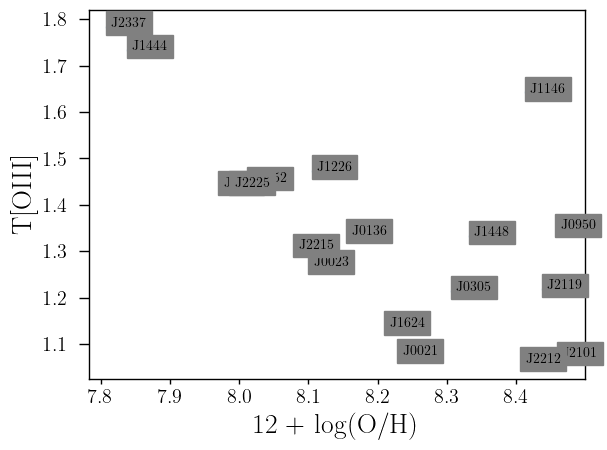

In [99]:
plt.scatter(abun_final['log_OH'], final_temden['tOIII_tot'], s=50)
for i in range(len(ft_dict['galname'])):
    plt.text(abun_final['log_OH'][i], final_temden['tOIII_tot'][i], final_temden['galname'][i], backgroundcolor='gray')
plt.ylabel('T[OIII]')
plt.xlabel('12 + log(O/H)')
plt.savefig('./t_vs_OH.pdf', bbox_inches='tight')

In [78]:
final_temden

,galname,tOIII_nar,tOIII_nar_16,tOIII_nar_84,tOIII_brd,tOIII_brd_16,tOIII_brd_84,tOIII_tot,tOIII_tot_16,tOIII_tot_84,...,tOII_84,ne,ne_16,ne_84,tNII,tNII_16,tNII_84,tSIII,tSIII_16,tSIII_84
0,J0021,1.072434,1.057341,1.087427,1.086760,1.040226,1.133990,1.078018,1.067005,1.089269,...,1.087711,122.642423,114.125649,130.856401,1.649604,1.579681,1.717332,1.000241,0.982139,1.018623
1,J0023,1.293199,1.282715,1.303087,0.853920,0.613497,1.052806,1.269386,1.259877,1.278971,...,1.218985,68.849669,59.259208,78.538842,NaN,NaN,NaN,1.378513,1.351117,1.406984
2,J0136,1.430147,1.403739,1.452895,0.921104,0.743109,1.092244,1.336618,1.320181,1.354071,...,1.207578,71.248006,37.588558,104.685982,NaN,NaN,NaN,1.286863,1.221800,1.358909
3,J0240,1.654751,1.639239,1.669755,1.105399,1.073071,1.137357,1.439954,1.431098,1.448774,...,1.696740,432.379554,377.923238,491.115361,2.767955,2.511583,3.009819,1.471492,1.403237,1.540873
4,J0252,1.337901,1.303516,1.371167,1.701615,1.591485,1.815212,1.449778,1.427285,1.472238,...,1.279548,114.212482,78.838534,151.012198,NaN,NaN,NaN,1.240441,1.172016,1.310766
5,J0305,1.209712,1.148668,1.267727,1.226809,1.082481,1.366473,1.214727,1.185016,1.245342,...,0.949107,115.258195,82.786506,149.238603,NaN,NaN,NaN,1.136600,1.078084,1.193805
6,J0950,1.499040,1.483651,1.514679,1.107363,1.070480,1.144168,1.347981,1.339840,1.356481,...,0.831349,84.243421,73.054752,96.649449,NaN,NaN,NaN,NaN,NaN,NaN
7,J1146,1.576938,1.556956,1.596716,2.022745,1.893315,2.158764,1.642331,1.633527,1.650954,...,0.777588,90.483762,61.628180,119.794822,NaN,NaN,NaN,NaN,NaN,NaN
8,J1226,1.542521,1.538286,1.546669,0.217801,-1.376700,0.593323,1.473875,1.470144,1.477603,...,1.038198,110.167167,97.929951,122.808458,1.083327,0.977806,1.194679,1.242851,1.217260,1.270207
9,J1444,1.729600,1.714897,1.745071,1.761809,1.632813,1.894497,1.733553,1.724300,1.742832,...,1.173659,169.202274,138.182157,202.804263,NaN,NaN,NaN,1.551272,1.495591,1.607819


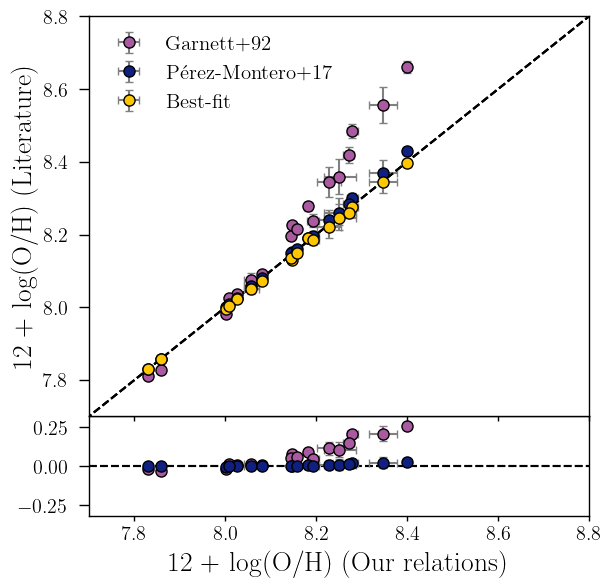

In [51]:
texPlot('on')
fig = plt.figure(1)
fig.set_size_inches(5, 5)
ax1 = fig.add_axes((0, 0, 1, .2))
ax = fig.add_axes((0, .2, 1, .8))


ax.plot(np.arange(7.5, 9.5, 0.1), np.arange(7.5, 9.5, 0.1), color='black', ls='--')
ax.errorbar(abun_dict['log_OH_me'], abun_dict['log_OH_G92'],
            xerr=log_OH_me_error, yerr=log_OH_G92_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=cz[1],
            markeredgecolor='black', label='Garnett+92')
ax.plot(np.arange(7.5, 9.5, 0.1), np.arange(7.5, 9.5, 0.1), color='black', ls='--')
ax.errorbar(abun_dict['log_OH_me'], abun_dict['log_OH_PM'],
            xerr=log_OH_me_error, yerr=log_OH_PM_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=cz[3],
            markeredgecolor='black', label='Pérez-Montero+17')
ax.plot(np.arange(7.5, 9.5, 0.1), np.arange(7.5, 9.5, 0.1), color='black', ls='--')
ax.errorbar(abun_dict['log_OH_me'], abun_dict['log_OH_new'],
            xerr=log_OH_me_error, yerr=log_OH_new_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=c[3],
            markeredgecolor='black', label='Best-fit')

ax.set_xlim(7.7, 8.8)
ax1.set_xlim(7.7, 8.8)
ax.set_ylim(7.7, 8.8)
ax.set_xticklabels([])

ax1.axhline(0, color='black', ls='--')
ax1.errorbar(abun_dict['log_OH_me'], abun_dict['log_OH_G92'] - abun_dict['log_OH_me'],
            xerr=log_OH_me_error, yerr=log_OH_G92_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=cz[1],
            markeredgecolor='black')
ax1.set_ylim(-0.32, 0.32)

ax1.axhline(0, color='black', ls='--')
ax1.errorbar(abun_dict['log_OH_me'], abun_dict['log_OH_PM'] - abun_dict['log_OH_me'],
            xerr=log_OH_me_error, yerr=log_OH_PM_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=cz[3],
            markeredgecolor='black')
ax1.set_ylim(-0.32, 0.32)

ax.set_ylabel('12 + log(O/H) (Literature)')
ax1.set_xlabel('12 + log(O/H) (Our relations)')
ax.legend(fontsize=15)
#fig.savefig('./OH_relations.pdf', bbox_inches='tight')

Text(0.5, 0, '12 + log(O/H) (Measured)')

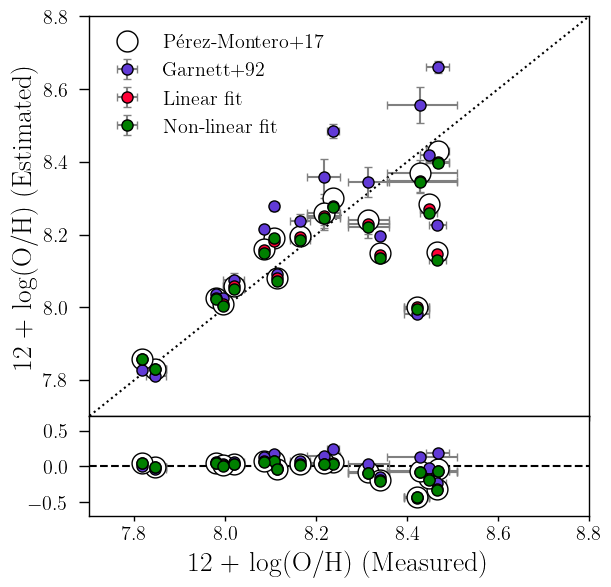

In [59]:
texPlot('on')
fig = plt.figure(1)
fig.set_size_inches(5, 5)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))



ax.errorbar(abun_dict['log_OH'], abun_dict['log_OH_PM'],
            xerr=log_OH_error, yerr=log_OH_PM_error,
            marker='o', markersize=15, capsize=3,
            ls='', ecolor='gray', color=c[3], mfc='w',
            markeredgecolor='black', label='Pérez-Montero+17')
ax.plot(np.arange(7.5, 9.5, 0.1), np.arange(7.5, 9.5, 0.1), color='black', ls=':')
ax.errorbar(abun_dict['log_OH'], abun_dict['log_OH_G92'],
            xerr=log_OH_error, yerr=log_OH_G92_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=c[2],
            markeredgecolor='black', label='Garnett+92')
ax.errorbar(x=abun_dict['log_OH'], y=abun_dict['log_OH_me'],
            xerr=log_OH_error, yerr=log_OH_me_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=c[1],
            markeredgecolor='black', label='Linear fit')
ax.errorbar(x=abun_dict['log_OH'], y=abun_dict['log_OH_new'],
            xerr=log_OH_error, yerr=log_OH_new_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color='green',
            markeredgecolor='black', label='Non-linear fit')
ax.set_xlim(7.7, 8.8)
ax1.set_xlim(7.7, 8.8)
ax.set_ylim(7.7, 8.8)
ax.set_xticklabels([])

ax1.errorbar(abun_dict['log_OH'], (abun_dict['log_OH_PM'] - abun_dict['log_OH']),
            xerr=log_OH_error, yerr=log_OH_PM_error,
            marker='o', markersize=15, capsize=3,
            ls='', ecolor='gray', color=c[3], mfc='w',
            markeredgecolor='black')
ax1.axhline(0, color='black', ls='--')
ax1.errorbar(abun_dict['log_OH'], (abun_dict['log_OH_G92'] - abun_dict['log_OH']),
            xerr=log_OH_error, yerr=log_OH_G92_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=c[2],
            markeredgecolor='black')
ax1.errorbar(abun_dict['log_OH'], (abun_dict['log_OH_me'] - abun_dict['log_OH']),
            xerr=log_OH_error, yerr=log_OH_me_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color=c[1],
            markeredgecolor='black')
ax1.errorbar(abun_dict['log_OH'], (abun_dict['log_OH_new'] - abun_dict['log_OH']),
            xerr=log_OH_error, yerr=log_OH_new_error,
            marker='o', markersize=8, capsize=3,
            ls='', ecolor='gray', color='green',
            markeredgecolor='black')


ax.legend()

ax1.set_ylim(-0.7, 0.7)

ax.set_ylabel('12 + log(O/H) (Estimated)')
ax1.set_xlabel('12 + log(O/H) (Measured)')

#fig.savefig('./OH_relations2.pdf', bbox_inches='tight')

In [55]:
print('Estimated scatter')
print('Linear fit:', round(np.std(abun_dict['log_OH_me'] - abun_dict['log_OH']), 3))
print('Garnett 1992:', round(np.std(abun_dict['log_OH_G92'] - abun_dict['log_OH']), 3))
print('Pérez-Montero+2017:', round(np.std(abun_dict['log_OH_me'] - abun_dict['log_OH']), 3))
print('Non-linear fit:', round(np.std(abun_dict['log_OH_me'] - abun_dict['log_OH']), 3))

Estimated scatter
Linear fit: 0.136
Garnett 1992: 0.16
Pérez-Montero+2017: 0.136
Non-linear fit: 0.136


In [147]:
abun_dict['log_OH_G92']

array([8.48444984, 8.27760425, 8.2381032 , 8.0358074 , 8.34547433,
       8.22737064, 7.98107935, 8.09183606, 7.81070394, 8.19651877,
       8.35742866, 8.660484  , 8.41844743, 8.555236  , 8.21505474,
       8.02609932, 7.82709123])

In [148]:
abun_dict['log_OH']

array([8.23664835, 8.10768457, 8.16459732, 7.97917488, 8.3146761 ,
       8.46678923, 8.42255749, 8.11305423, 7.84461607, 8.33946035,
       8.21649089, 8.46777406, 8.44711223, 8.42763368, 8.08565421,
       7.99417487, 7.81571085])

In [156]:
abun_dict['galname']

array(['J0021', 'J0023', 'J0136', 'J0240', 'J0305', 'J0950', 'J1146',
       'J1226', 'J1444', 'J1448', 'J1624', 'J2101', 'J2119', 'J2212',
       'J2215', 'J2225', 'J2337'], dtype=object)

In [ ]:
for i in range(len(abun_dict['galname'])):
    
    print(abun_dict['galname'][i],
          round(abun_dict['log_OH_G92'][i], 3),
          round(abun_dict['log_OH_G92'][i] - abun_dict['log_OH_G92_16'][i], 3),
          round(abun_dict['log_OH_G92_84'][i] - abun_dict['log_OH_G92'][i], 3))

In [ ]:
np.max(np.abs(abun_dict['log_OH_G92'] - abun_dict['log_OH']))

In [ ]:
np.max(np.abs(abun_dict['log_OH_me'] - abun_dict['log_OH']))

In [ ]:
plt.hist(abun_dict['log_OH'], bins=np.arange(7.8, 8.8, 0.1), histtype='step')
plt.hist(abun_dict['log_OH_G92'], bins=np.arange(7.8, 8.8, 0.1), histtype='step')
plt.hist(abun_dict['log_OH_me'], bins=np.arange(7.8, 8.8, 0.1), histtype='step')

In [ ]:
np.max(abun_dict['log_OH_G92'] - abun_dict['log_OH_me'])

In [ ]:
np.min(abun_dict['log_OH_G92'] - abun_dict['log_OH_me'])

----

In [42]:
# Read results

# Metallicities and ratios
total_temden = pd.read_csv(magePath+'results/metals/temden_lines.csv')
#broad = pd.read_csv(magePath+'results/metals/temden_broad_corr_cal.csv')

# Emission line fluxes
total_lines = pd.read_csv(magePath+'results/em_lines.csv') 
#narrow_lines = pd.read_csv(magePath+'results/em_narrow.csv') 
#broad_lines = pd.read_csv(magePath+'results/em_broad.csv') 

## mask to filter NII5755 detection (TN2 measurements)
#n2_detect = ['J0021', 'J0240', 'J0950', 'J1226', 'J1448', 'J2215']
#mask_nii = []
#for galaxy in total_temden['Source']:
#    if galaxy in n2_detect:
#        mask_nii.append(True)
#    else:
#        mask_nii.append(False)
#
#
#total_temden.keys()

In [44]:
total_temden['ne_OII']

0     122.527089
1      69.149227
2      72.499951
3     439.544962
4     104.328097
5     109.876758
6      91.704454
7      60.646716
8     141.564716
9     173.686470
10    127.591145
11    117.322994
12    122.795626
13     45.762294
14    160.281977
15     77.452270
16     64.797251
17    168.094150
Name: ne_OII, dtype: float64

In [ ]:
texPlot('on')
fig, axs = plt.subplots(1, 3)
fig.set_size_inches((20, 5))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

# Comparison between densities calculated with T_high
# and consistent T_low(OII)
axs[0].errorbar(total['ne_OIII'], total['ne_OII'],
                   xerr = total['ne_OIII_err'],
                   yerr = total['ne_OII_err'],
                   marker='s', markersize=10, ls='', alpha=0.5,
                   ecolor='gray', label='from T[OII]', color=cz[0])
axs[0].errorbar(total['ne_OIII'], total['ne_SII'],
                   xerr = total['ne_OIII_err'],
                   yerr = total['ne_SII_err'],
                   marker='o', markersize=10, ls='', alpha=0.5,
                   ecolor='gray', label='from T[SII]', color=cz[3])
axs[0].plot(np.arange(0.0, 600.0, 1), np.arange(0.0, 600.0, 1),
              ls=':', color='black')
axs[0].set_xlim(0.0, 600.)
axs[0].set_ylim(0.0, 600.)
axs[0].set_xlabel(r'$n_{e}$([SII]) from T[OIII] (cm$^{-3}$)', fontsize=15)
axs[0].set_ylabel(r'$n_{e}$([SII]) (cm$^{-3}$)', fontsize=15)
axs[0].legend()

# Other comparison of the previous plot using the difference with the
# 1:1 relation
axs[1].errorbar(total['ne_OIII'], upy.nominal_values(delta_O3O2),
                   xerr = total['ne_OIII_err'],
                   yerr = upy.std_devs(delta_O3O2),
                   marker='s', markersize=10, ls='', markeredgecolor='black',
                   ecolor='gray', color=cz[0])
axs[1].errorbar(total['ne_OIII'], upy.nominal_values(delta_O3S2),
                   xerr = total['ne_OIII_err'],
                   yerr = upy.std_devs(delta_O3O2),
                   marker='o', markersize=10, ls='', markeredgecolor='black',
                   ecolor='gray', color=cz[3])
axs[1].axhline(0.0, lw=4, color='red', label='$\Delta n_{e} = 0$')
axs[1].axhline(30.0, ls=':', color='red', label='$|\Delta n_{e}| = 30$')
axs[1].axhline(-30.0, ls=':', color='red')
axs[1].legend(frameon=True, framealpha=1, edgecolor='black', fancybox=False)

axs[1].set_xlabel(r'$ n_{e}$([SII]) from T[OIII] (cm$^{-3}$)', fontsize=15)
axs[1].set_ylabel(r'$\Delta n_{e}$([SII]) (cm$^{-3}$)', fontsize=15)


# Comparison between densities calculated with TSII and TOII consistently
axs[2].errorbar(total['ne_OII'], total['ne_SII'],
                   xerr = total['ne_OII_err'],
                   yerr = total['ne_SII_err'],
                   marker='d', markersize=10, ls='', markeredgecolor='black',
                   ecolor='gray', color=cz[0])
axs[2].plot(np.arange(0.0, 600.0, 1), np.arange(0.0, 600.0, 1),
              ls=':', color='black')
axs[2].set_xlim(0.0, 550.)
axs[2].set_ylim(0.0, 550.)
axs[2].set_xlabel(r'$n_{e}$([SII]) from T[OII] (cm$^{-3}$)', fontsize=15)
axs[2].set_ylabel(r'$n_{e}$([SII]) from T[SII] (cm$^{-3}$)', fontsize=15)
#fig.savefig('/home/benjamin/Documents/analogs/results/metals/n_t2.jpg', dpi=500,
#           facecolor='white', bbox_inches='tight')

In [ ]:

fig = plt.figure()
fig.set_size_inches((6, 3))


ax = fig.add_axes([0, 0, 0.5, 1], projection='3d')
ax.scatter(total['ne_OIII'], total['ne_OII'], total['ne_SII'],
           alpha=1.0, color=cr[2], edgecolor='black', s=200,
           marker='*'
)

ax.plot(np.arange(0.0, 600.0, 1), np.arange(0.0, 600.0, 1), np.arange(0.0, 600.0, 1),
        color='black', ls=':')

ax.set_xlabel('$n_{e}$(T$_{e}$[OIII])', fontsize=15, labelpad=10)
ax.set_ylabel('$n_{e}$(T$_{e}$[OII])', fontsize=15, labelpad=10)
ax.set_zlabel('$n_{e}$(T$_{e}$[SII])', fontsize=15, labelpad=10)

ax1 = fig.add_axes([0.8, 0, 0.5, 1], projection='rectilinear')

ax1.errorbar(x=total['ne_OII'], y=total['ne_SII'],
            xerr=total['ne_OII_err'], yerr=total['ne_SII_err'],
            ls='', marker='*', markersize=15, ecolor='gray',
            color=cr[2], markeredgecolor='black',
)
ax1.plot(np.arange(0.0, 600.0, 1), np.arange(0.0, 600.0, 1),
              ls=':', color='black')
ax1.set_xlim(0.0, 550.)
ax1.set_ylim(0.0, 550.)
ax1.set_xlabel('$n_{e}$(T$_{e}$[OII])', fontsize=15)
ax1.set_ylabel('$n_{e}$(T$_{e}$[SII])', fontsize=15)



ax2 = fig.add_axes([0, -1.3, 0.5, 1], projection='rectilinear')

ax2.errorbar(x=total['ne_OIII'], y=total['ne_OII'],
            xerr=total['ne_OIII_err'], yerr=total['ne_OII_err'],
            ls='', marker='*', markersize=15, ecolor='gray',
            color=cr[2], markeredgecolor='black',
)
ax2.plot(np.arange(0.0, 600.0, 1), np.arange(0.0, 600.0, 1),
              ls=':', color='black')
ax2.set_xlim(0.0, 550.)
ax2.set_ylim(0.0, 550.)
ax2.set_xlabel('$n_{e}$(T$_{e}$[OIII])', fontsize=15)
ax2.set_ylabel('$n_{e}$(T$_{e}$[OII])', fontsize=15)



ax3 = fig.add_axes([0.8, -1.3, 0.5, 1], projection='rectilinear')

ax3.errorbar(x=total['ne_OIII'], y=total['ne_SII'],
            xerr=total['ne_OIII_err'], yerr=total['ne_SII_err'],
            ls='', marker='*', markersize=15, ecolor='gray',
            color=cr[2], markeredgecolor='black',
)
ax3.plot(np.arange(0.0, 600.0, 1), np.arange(0.0, 600.0, 1),
              ls=':', color='black')
ax3.set_xlim(0.0, 550.)
ax3.set_ylim(0.0, 550.)
ax3.set_xlabel('$n_{e}$(T$_{e}$[OIII])', fontsize=15)
ax3.set_ylabel('$n_{e}$(T$_{e}$[SII])', fontsize=15)

In [ ]:
dO3O2_mean

In [ ]:

fig = plt.figure()
fig.set_size_inches((6, 3))

ax1 = fig.add_axes([0, 0, 0.5, 1], projection='rectilinear')

ax1.errorbar(x=total['ne_OIII'], y=total['ne_OII'],
            xerr=total['ne_OIII_err'], yerr=total['ne_OII_err'],
            ls='', marker='s', markersize=10, ecolor='gray',
            markeredgecolor='black', color=cz[0]
)
ax1.plot(np.arange(0.0, 600.0, 1), np.arange(0.0, 600.0, 1),
              ls=':', color='black')
ax1.set_xlim(0.0, 550.)
ax1.set_ylim(0.0, 550.)
ax1.set_xlabel('$n_{e}$(T$_{e}$[OIII]) (cm$^{-3}$)', fontsize=15)
ax1.set_ylabel('$n_{e}$(T$_{e}$[OII]) (cm$^{-3}$)', fontsize=15)



ax3 = fig.add_axes([0.7, 0., 0.5, 1], projection='rectilinear')

ax3.errorbar(total['ne_OIII'], upy.nominal_values(delta_O3O2),
                   xerr = total['ne_OIII_err'],
                   yerr = upy.std_devs(delta_O3O2),
                   marker='s', markersize=10, ls='', markeredgecolor='black',
                   ecolor='gray', color=cz[0])
ax3.axhline(0.0, lw=3, color='black', label='$\Delta n_{e} = 0$')
ax3.axhline(dO3O2_mean, lw=2, ls='--', color=cz[0], label=r'$\langle\Delta n_{e}\rangle$ = ' +'{:.2f}'.format(dO3O2_mean) + r' $\pm$ ' + '{:.2f}'.format(dO3O2_std))
ax3.legend(frameon=True, framealpha=1, edgecolor='black', fancybox=False, fontsize=10)
ax3.set_ylim(-30, 30)
ax3.set_xlabel(r'$n_{e}$(T$_{e}$[OIII]) (cm$^{-3}$)', fontsize=15)
ax3.set_ylabel(r'$\Delta n_{e}$ (cm$^{-3}$)', fontsize=15)

#fig.savefig('./densities.pdf', bbox_inches='tight')

# Temperatures

In [ ]:
broad.keys()

In [ ]:
fig, axs = plt.subplots(3, 3)
fig.set_size_inches((15, 15))
fig.subplots_adjust(wspace=0.4, hspace=0.4)


# ========================================================================
#
# First row, low ionization temperatures
#
# ========================================================================


# Relation between t(OII) and t(NII)
axs[0, 0].errorbar(total['t(OII)_ne'], total['t(NII)'],
                   xerr = total['t(OII)_ne_err'],
                   yerr = total['t(NII)_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')

axs[0, 0].plot(np.arange(0.5, 4.0, 0.01), np.arange(0.5, 4.0, 0.01),
              ls=':', color='black')
axs[0, 0].plot(C16('TN2', 'TO2')[0], C16('TN2', 'TO2')[1],
              ls='--', label='Croxall+2016', color='blue')
axs[0, 0].plot(B20('TN2', 'TO2')[0], B20('TN2', 'TO2')[1],
              ls='--', label='Berg+2020', color='red')
axs[0, 0].set_xlim(0.5, 3.5)
axs[0, 0].set_ylim(0.5, 3.5)
axs[0, 0].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[0, 0].set_xlabel(r'T$_{e}$[OII] ($10^{4}$ K)')


# Relation between t(SII) and t(NII)
axs[0, 1].errorbar(total['t(SII)_ne'], total['t(NII)'],
                   xerr = total['t(SII)_ne_err'],
                   yerr = total['t(NII)_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[0, 1].plot(np.arange(0.5, 5.0, 0.01), np.arange(0.5, 5.0, 0.01),
              ls=':', color='black')
axs[0, 1].plot(B20('TN2', 'TS2')[0], B20('TN2', 'TS2')[1],
              ls='--', label='Berg+2020', color='red')
axs[0, 1].set_xlim(0.5, 5.0)
axs[0, 1].set_ylim(0.5, 5.0)
axs[0, 1].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[0, 1].set_xlabel(r'T$_{e}$[SII] ($10^{4}$ K)')


# Relation between t(SII) and t(OII)
axs[0, 2].errorbar(total['t(SII)_ne'], total['t(OII)_ne'],
                   xerr = total['t(SII)_ne_err'],
                   yerr = total['t(OII)_ne_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[0, 2].plot(np.arange(0.5, 8.0, 0.01), np.arange(0.5, 8.0, 0.01),
              ls=':', color='black')
axs[0, 2].plot(PM17('TS2', 'TO2')[1], PM17('TS2', 'TO2')[0],
              ls='-.', label='Pérez-Montero+2017', color='orange')
axs[0, 2].set_xlim(0.5, 8.0)
axs[0, 2].set_ylim(0.5, 8.0)
axs[0, 2].set_ylabel(r'T$_{e}$[OII] ($10^{4}$ K)')
axs[0, 2].set_xlabel(r'T$_{e}$[SII] ($10^{4}$ K)')

# ========================================================================
#
# Second row, relations with TS3 (Intermedium ionization zone)
#
# ========================================================================

# Relation between t(SIII) and t(OIII)
axs[1, 0].errorbar(total['t(SIII)'], total['t(OIII)'],
                   xerr = total['t(SIII)_err'],
                   yerr = total['t(OIII)_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[1, 0].plot(np.arange(0.5, 6.0, 0.01), np.arange(0.5, 6.0, 0.01),
              ls=':', color='black', label='1:1')
axs[1, 0].plot(G92('TS3', 'TO3')[1], G92('TS3', 'TO3')[0],
              ls='-.', label='Garnett+1992', color='green')
axs[1, 0].plot(PM17('TO3', 'TS3')[1], PM17('TO3', 'TS3')[0],
              ls='-.', label='Pérez-Montero+2017', color='orange')
axs[1, 0].plot(C16('TS3', 'TO3')[1], C16('TS3', 'TO3')[0],
              ls='--', label='Croxall+2016', color='blue')
axs[1, 0].plot(B20('TO3', 'TS3')[1], B20('TO3', 'TS3')[0],
              ls='--', label='Berg+2020', color='red')
axs[1, 0].set_xlim(0.5, 5.0)
axs[1, 0].set_ylim(0.5, 5.0)
axs[1, 0].set_ylabel(r'T$_{e}$[OIII] ($10^{4}$ K)')
axs[1, 0].set_xlabel(r'T$_{e}$[SIII] ($10^{4}$ K)')
axs[1, 0].legend(loc=(4.1, 0), fontsize=25)

# Relation between t(SIII) and t(NII)
axs[1, 1].errorbar(total['t(SIII)'], total['t(NII)'],
                   xerr = total['t(SIII)_err'],
                   yerr = total['t(NII)_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[1, 1].plot(np.arange(0.5, 4.0, 0.01), np.arange(0.5, 4.0, 0.01),
              ls=':', color='black')
axs[1, 1].plot(C16('TS3', 'TN2')[1], C16('TS3', 'TN2')[0],
              ls='--', label='Croxall+2016', color='blue')
axs[1, 1].plot(B20('TN2', 'TS3')[1], B20('TN2', 'TS3')[0],
              ls='--', label='Berg+2020', color='red')
axs[1, 1].set_xlim(0.5, 4.0)
axs[1, 1].set_ylim(0.5, 4.0)
axs[1, 1].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[1, 1].set_xlabel(r'T$_{e}$[SIII] ($10^{4}$ K)')


# Relation between t(SIII) and t(SII)
axs[1, 2].errorbar(total['t(SIII)'], total['t(SII)_ne'],
                   xerr = total['t(SIII)_err'],
                   yerr = total['t(SII)_ne_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[1, 2].plot(np.arange(0.5, 8.0, 0.01), np.arange(0.5, 8.0, 0.01),
              ls=':', color='black')
axs[1, 2].set_xlim(0.5, 8.0)
axs[1, 2].set_ylim(0.5, 8.0)
axs[1, 2].set_ylabel(r'T$_{e}$[SII] ($10^{4}$ K)')
axs[1, 2].set_xlabel(r'T$_{e}$[SIII] ($10^{4}$ K)')

# Relation between t(SIII) and t(OII)
axs[2, 1].errorbar(total['t(SIII)'], total['t(OII)_ne'],
                   xerr = total['t(SIII)_err'],
                   yerr = total['t(OII)_ne_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[2, 1].plot(np.arange(0.5, 5.0, 0.01), np.arange(0.5, 5.0, 0.01),
              ls=':', color='black')
axs[2, 1].set_xlim(0.5, 5.0)
axs[2, 1].set_ylim(0.5, 5.0)
axs[2, 1].set_ylabel(r'T$_{e}$[OII] ($10^{4}$ K)')
axs[2, 1].set_xlabel(r'T$_{e}$[SIII] ($10^{4}$ K)')

# ========================================================================
#
# Third row, relations with TO3 (High ionization zone)
#
# ========================================================================


# Relation between t(OIII) and t(NII)
axs[2, 0].errorbar(total['t(OIII)'], total['t(NII)'],
                   xerr = total['t(OIII)_err'],
                   yerr = total['t(NII)_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[2, 0].plot(np.arange(0.5, 4.0, 0.01), np.arange(0.5, 4.0, 0.01),
              ls=':', color='black')
axs[2, 0].plot(PM17('TN2', 'TO3')[0], PM17('TN2', 'TO3')[1],
              ls='-.', label='Peréz-Montero+2017', color='orange')
axs[2, 0].set_xlim(0.5, 3.5)
axs[2, 0].set_ylim(0.5, 3.5)
axs[2, 0].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[2, 0].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')


# Relation between t(OIII) and t(OII)
#axs[2, 1].errorbar(total['t(OIII)'], total['t(OII)_ne'],
#                   xerr = total['t(OIII)_err'],
#                   yerr = total['t(OII)_ne_err'],
#                   marker='s', markersize=10, ls='',
#                   ecolor='gray', color=cr[2], markeredgecolor='black')
#axs[2, 1].plot(np.arange(0.5, 4.0, 0.01), np.arange(0.5, 4.0, 0.01),
#              ls=':', color='black')
#axs[2, 1].plot(G92('TO3', 'TO2')[0], G92('TO3', 'TO2')[1],
#              ls='-.', label='Garnett+1992', color='green')
#axs[2, 1].plot(PM17('TO3', 'TO2')[0], PM17('TO3', 'TO2')[1],
#              ls='-.', label='Peréz-Montero+2017', color='orange')
#axs[2, 1].set_xlim(0.5, 2.5)
#axs[2, 1].set_ylim(0.5, 2.5)
#axs[2, 1].set_ylabel(r'T$_{e}$[OII] ($10^{4}$ K)')
#axs[2, 1].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')


# Relation between t(OIII) and t(OII)
axs[2, 2].errorbar(total['t(OIII)'], total['t(SII)_ne'],
                   xerr = total['t(OIII)_err'],
                   yerr = total['t(SII)_ne_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[2, 2].plot(np.arange(0.5, 8.0, 0.01), np.arange(0.5, 8.0, 0.01),
               ls=':', color='black')
axs[2, 2].set_xlim(0.5, 8.0)
axs[2, 2].set_ylim(0.5, 8.0)
axs[2, 2].set_ylabel(r'T$_{e}$[SII] ($10^{4}$ K)')
axs[2, 2].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')

# Axis off
#axs[0, 3].axis('off')
#axs[2, 3].axis('off')
#fig.savefig('/home/benjamin/Documents/analogs/results/metals/temp_relations.jpg', dpi=500,
#           facecolor='white', bbox_inches='tight')

# Main / Important relations

In [ ]:
import corner
from lmfit import minimize, Parameters

params_to3_ts3 = Parameters()
params_to3_ts3.add('m', value=1.3, min=0.)
params_to3_ts3.add('n', value=-0.3, min=0.)

def residual_to3_ts3(params_to3_ts3, x, data, uncertainty):
    m = params_to3_ts3['m']
    n = params_to3_ts3['n']
    mask_outliers = (total['t(SIII)'].to_numpy() < 3)
    
    x = total['t(OIII)'].to_numpy()[mask_outliers]
    y = total['t(SIII)'].to_numpy()[mask_outliers]
    err = total['t(SIII)_err'].to_numpy()[mask_outliers]
    
    model = (m * x) + n
    return (model - y) / 

In [ ]:
fig, axs = plt.subplots(1, 2)
fig.set_size_inches((14, 6))
fig.subplots_adjust(wspace=0.4, hspace=0.4)

# Relation between t(OIII) and t(OII)
axs[1].errorbar(total['t(OIII)'], total['t(OII)_ne'],
                   xerr = total['t(OIII)_err'],
                   yerr = total['t(OII)_ne_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')

axs[1].plot(np.arange(0.5, 4.0, 0.01), np.arange(0.5, 4.0, 0.01),
              ls=':', color='black')
axs[1].plot(G92('TO3', 'TO2')[0], G92('TO3', 'TO2')[1],
              ls='-.', label='Garnett+1992', color='green')
axs[1].plot(PM17('TO3', 'TO2')[0], PM17('TO3', 'TO2')[1],
              ls='-.', label='Peréz-Montero+2017', color='orange')
axs[1].set_xlim(0.5, 2.2)
axs[1].set_ylim(0.5, 2.2)
axs[1].set_ylabel(r'T$_{e}$[OII] ($10^{4}$ K)')
axs[1].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')
#axs[0].legend(frameon=True, framealpha=1, edgecolor='black', fancybox=False)
#fig.savefig('/home/benjamin/Documents/analogs/results/metals/O3vsO2.pdf', dpi=300, 
#           facecolor='white', bbox_inches='tight')

# Relation between t(OIII) and t(SIII)
axs[0].errorbar(total['t(OIII)'], total['t(SIII)'],
                   xerr = total['t(OIII)_err'],
                   yerr = total['t(SIII)_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[0].plot(np.arange(0.5, 6.0, 0.01), np.arange(0.5, 6.0, 0.01),
              ls=':', color='black', label='1:1')
axs[0].plot(G92('TS3', 'TO3')[0], G92('TS3', 'TO3')[1],
              ls='-.', label='Garnett+1992', color='green')
axs[0].plot(PM17('TO3', 'TS3')[0], PM17('TO3', 'TS3')[1],
              ls='-.', label='Pérez-Montero+2017', color='orange')
axs[0].plot(C16('TS3', 'TO3')[0], C16('TS3', 'TO3')[1],
              ls='--', label='Croxall+2016', color='blue')
axs[0].plot(B20('TO3', 'TS3')[0], B20('TO3', 'TS3')[1],
              ls='--', label='Berg+2020', color='red')
axs[0].set_xlim(0.5, 2.5)
axs[0].set_ylim(0.5, 2.5)
axs[0].set_ylabel(r'T$_{e}$[SIII] ($10^{4}$ K)')
axs[0].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')
axs[0].legend(loc=(2.5, 0),
              frameon=False, framealpha=1, edgecolor='black',
              fancybox=False, fontsize=20)


'''
# Relation between t(SIII) and t(OII)
axs[1, 0].errorbar(total['t(SIII)'], total['t(OII)_ne'],
                   xerr = total['t(SIII)_err'],
                   yerr = total['t(OII)_ne_err'],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[1, 0].plot(np.arange(0.5, 5.0, 0.01), np.arange(0.5, 5.0, 0.01),
              ls=':', color='black')
axs[1, 0].set_xlim(0.5, 2.5)
axs[1, 0].set_ylim(0.5, 2.5)
axs[1, 0].set_ylabel(r'T$_{e}$[OII] ($10^{4}$ K)')
axs[1, 0].set_xlabel(r'T$_{e}$[SIII] ($10^{4}$ K)')

# Relation between t(OIII) and t(NII)
axs[1, 1].errorbar(total['t(OIII)'][mask_nii], total['t(NII)'][mask_nii],
                   xerr = total['t(OIII)_err'][mask_nii],
                   yerr = total['t(NII)_err'][mask_nii],
                   marker='o', markersize=10, ls='',
                   ecolor='gray', color=cr[2], markeredgecolor='black')
axs[1, 1].plot(np.arange(0.5, 4.0, 0.01), np.arange(0.5, 4.0, 0.01),
              ls=':', color='black')
axs[1, 1].plot(PM17('TN2', 'TO3')[0], PM17('TN2', 'TO3')[1],
              ls='-.', label='Peréz-Montero+2017', color='orange')
axs[1, 1].set_xlim(0.5, 3.5)
axs[1, 1].set_ylim(0.5, 3.5)
axs[1, 1].set_ylabel(r'T$_{e}$[NII] ($10^{4}$ K)')
axs[1, 1].set_xlabel(r'T$_{e}$[OIII] ($10^{4}$ K)')''';